In [ ]:
#2024.11.30

import pandas as pd 
import numpy as np
import gc
# all MOFs including the theoretical ones
dfrac = pd.read_csv('./RACs.csv')                  # all MOFs including the theoretical ones
dfgeo = pd.read_csv('./geometric_properties.csv')  # the geometric descriptors
dfX = pd.read_csv('./20MOFX.csv')                  # MOFs used in this study

In [191]:
dfrac_EMOF=dfrac.iloc[list(np.where(dfrac['DB_num']=='DB14')[0])+list(np.where(dfrac['DB_num']=='DB12')[0])]    # include experimentally available MOFs
dfgeo_EMOF=dfgeo.iloc[list(np.where(dfgeo['DB_num']=='DB14')[0])+list(np.where(dfgeo['DB_num']=='DB12')[0])]

In [192]:
#remove unuseful columns
dfrac = dfrac.iloc[:, 1:-10]
dfgeo = dfgeo.iloc[:, 1:-4]
dfrac_EMOF = dfrac_EMOF.iloc[:, 1:-10]
dfgeo_EMOF = dfgeo_EMOF.iloc[:, 1:-4]

In [193]:
# Assuming you have two DataFrames df and dfg with a common column 'filename'
# Merging the DataFrames on 'filename' with inner join to keep only common entries
merged_df = pd.merge(dfrac, dfgeo, on='filename', how='inner')
merged_df_EMOF = pd.merge(dfrac_EMOF, dfgeo_EMOF, on='filename', how='inner')
del dfrac  # Delete the DataFrame
del dfgeo  # Delete the DataFrame
del dfrac_EMOF  # Delete the DataFrame
del dfgeo_EMOF  # Delete the DataFrame
gc.collect()  # Run garbage collection

88003

In [ ]:
#Remove the columns that has low variance
from sklearn.preprocessing import StandardScaler
import numpy as np

merged_df.replace([np.inf, -np.inf], np.nan, inplace=True)
merged_df.dropna(inplace=True)
merged_df_EMOF.replace([np.inf, -np.inf], np.nan, inplace=True)
merged_df_EMOF.dropna(inplace=True)

# make sure all the columns are numerical values
# merged_df = merged_df.select_dtypes(include=[np.number])

print(merged_df.shape)

# standardize
scaler = StandardScaler()
scaler.fit(merged_df.drop(columns=['filename']))
# convert the raw data using the standardizing method
scaled_merged_df = scaler.transform(merged_df.drop(columns=['filename']))  #all MOFs
MOF_index = dfX['MOF_index']
MOF_name = dfX['MOF']
dfX = dfX[merged_df.drop(columns=['filename']).columns]
scaled_dfX = scaler.transform(dfX)   #MOFs used in this study
dfEMOF = merged_df_EMOF[merged_df.drop(columns=['filename']).columns]  #experimentally available MOFs
scaled_dfEMOF = scaler.transform(dfEMOF)
# data standardization
df_standardized = pd.DataFrame(scaled_merged_df, columns=merged_df.drop(columns=['filename']).columns)
print(df_standardized.shape)
dfX_standardized = pd.DataFrame(scaled_dfX, columns=dfX.columns)
print(dfX_standardized.shape)
dfEMOF_standardized = pd.DataFrame(scaled_dfEMOF, columns=dfEMOF.columns)
print(dfEMOF_standardized.shape)

# del merged_df  # Delete the DataFrame
# gc.collect()  # Run garbage collection

# Remove the columns that has low variance
column_to_keep = (df_standardized.std() > 0) # a number that can be ajusted
df_standardized = df_standardized.loc[:, column_to_keep]  
dfX_standardized = dfX_standardized.loc[:, column_to_keep]  
dfEMOF_standardized = dfEMOF_standardized.loc[:, column_to_keep]
print(df_standardized.shape)
print(dfX_standardized.shape)
print(dfEMOF_standardized.shape)

In [ ]:
dfEMOF_standardized.shape

In [195]:
#Test if factor analysis is suitable
import pandas as pd
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

# # removing low variance columns
# df_standardized = df_standardized.loc[:, df_standardized.std() > 0.05]  # adjustable number

# examining feasibility using some figure of merits
chi_square_value, p_value = calculate_bartlett_sphericity(df_standardized.values)
kmo_all, kmo_model = calculate_kmo(df_standardized.values)

# the results
print("Bartlett's Test Value:", chi_square_value, "P-value:", p_value)
print("KMO Test Value:", kmo_model)



d:\Anaconda3\envs\rdkit\lib\site-packages\factor_analyzer\factor_analyzer.py:109: RuntimeWarning: divide by zero encountered in log
  statistic = -np.log(corr_det) * (n - 1 - (2 * p + 5) / 6)
d:\Anaconda3\envs\rdkit\lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


Bartlett's Test Value: inf P-value: 0.0
KMO Test Value: 0.8350236044589023


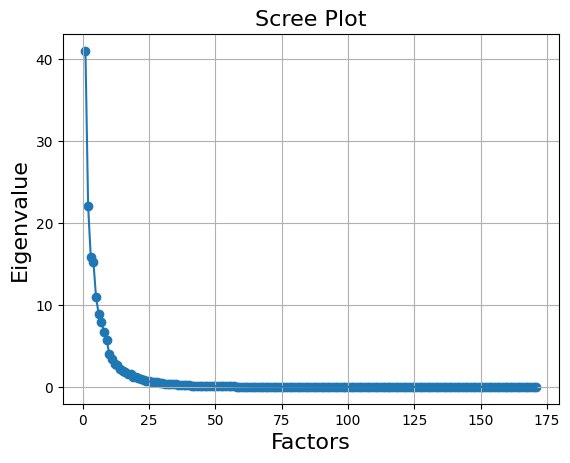

45


In [196]:
from matplotlib import pyplot as plt
# select the number of factors
fa = FactorAnalyzer(rotation=None, n_factors=3, method='minres')
fa.fit(df_standardized.values)

# factor loadings
loadings = fa.loadings_
# print(loadings)

# Scree plot for determining the number of factors

ev, v = fa.get_eigenvalues()
plt.scatter(range(1, df_standardized.shape[1]+1), ev)
plt.plot(range(1, df_standardized.shape[1]+1), ev)
plt.title('Scree Plot', fontsize=16)
plt.xlabel('Factors',fontsize=16)
plt.ylabel('Eigenvalue',fontsize=16)
plt.grid()
plt.show()
#selected the number of factors to consider
consider_threshold = 0.1
Num_factor_selected = sum(ev>consider_threshold)
print(Num_factor_selected)

In [197]:

# initializing the factor
fa = FactorAnalyzer(n_factors=Num_factor_selected, rotation='varimax')  # n_factors is the number of factors，adjustable
# fa = FactorAnalyzer(n_factors=Num_factor_selected, rotation=None)  # n_factors is the number of factors，adjustable
# factor analysis
fa.fit(df_standardized.values)  #on all MOFs

# get factor loadings
factor_loadings = fa.loadings_

# convert loadings to DataFrame
columns = [f'Factor{i+1}' for i in range(factor_loadings.shape[1])]
loadings_df = pd.DataFrame(factor_loadings, index=df_standardized.columns, columns=columns)

In [198]:
#calculate the Bartlett scores
n_factors = factor_loadings.shape[1]
lambda_ = 0.001  # regularization parameter
I = np.eye(fa.corr_.shape[0])  
model_implied_cov_inv = np.linalg.pinv(fa.corr_+I)
factor_score_coefficients = np.linalg.pinv(factor_loadings.T @ model_implied_cov_inv @ factor_loadings) @ factor_loadings.T @ model_implied_cov_inv
factor_score_coefficients_df = pd.DataFrame(factor_score_coefficients.T, index=df_standardized.columns, columns=columns)

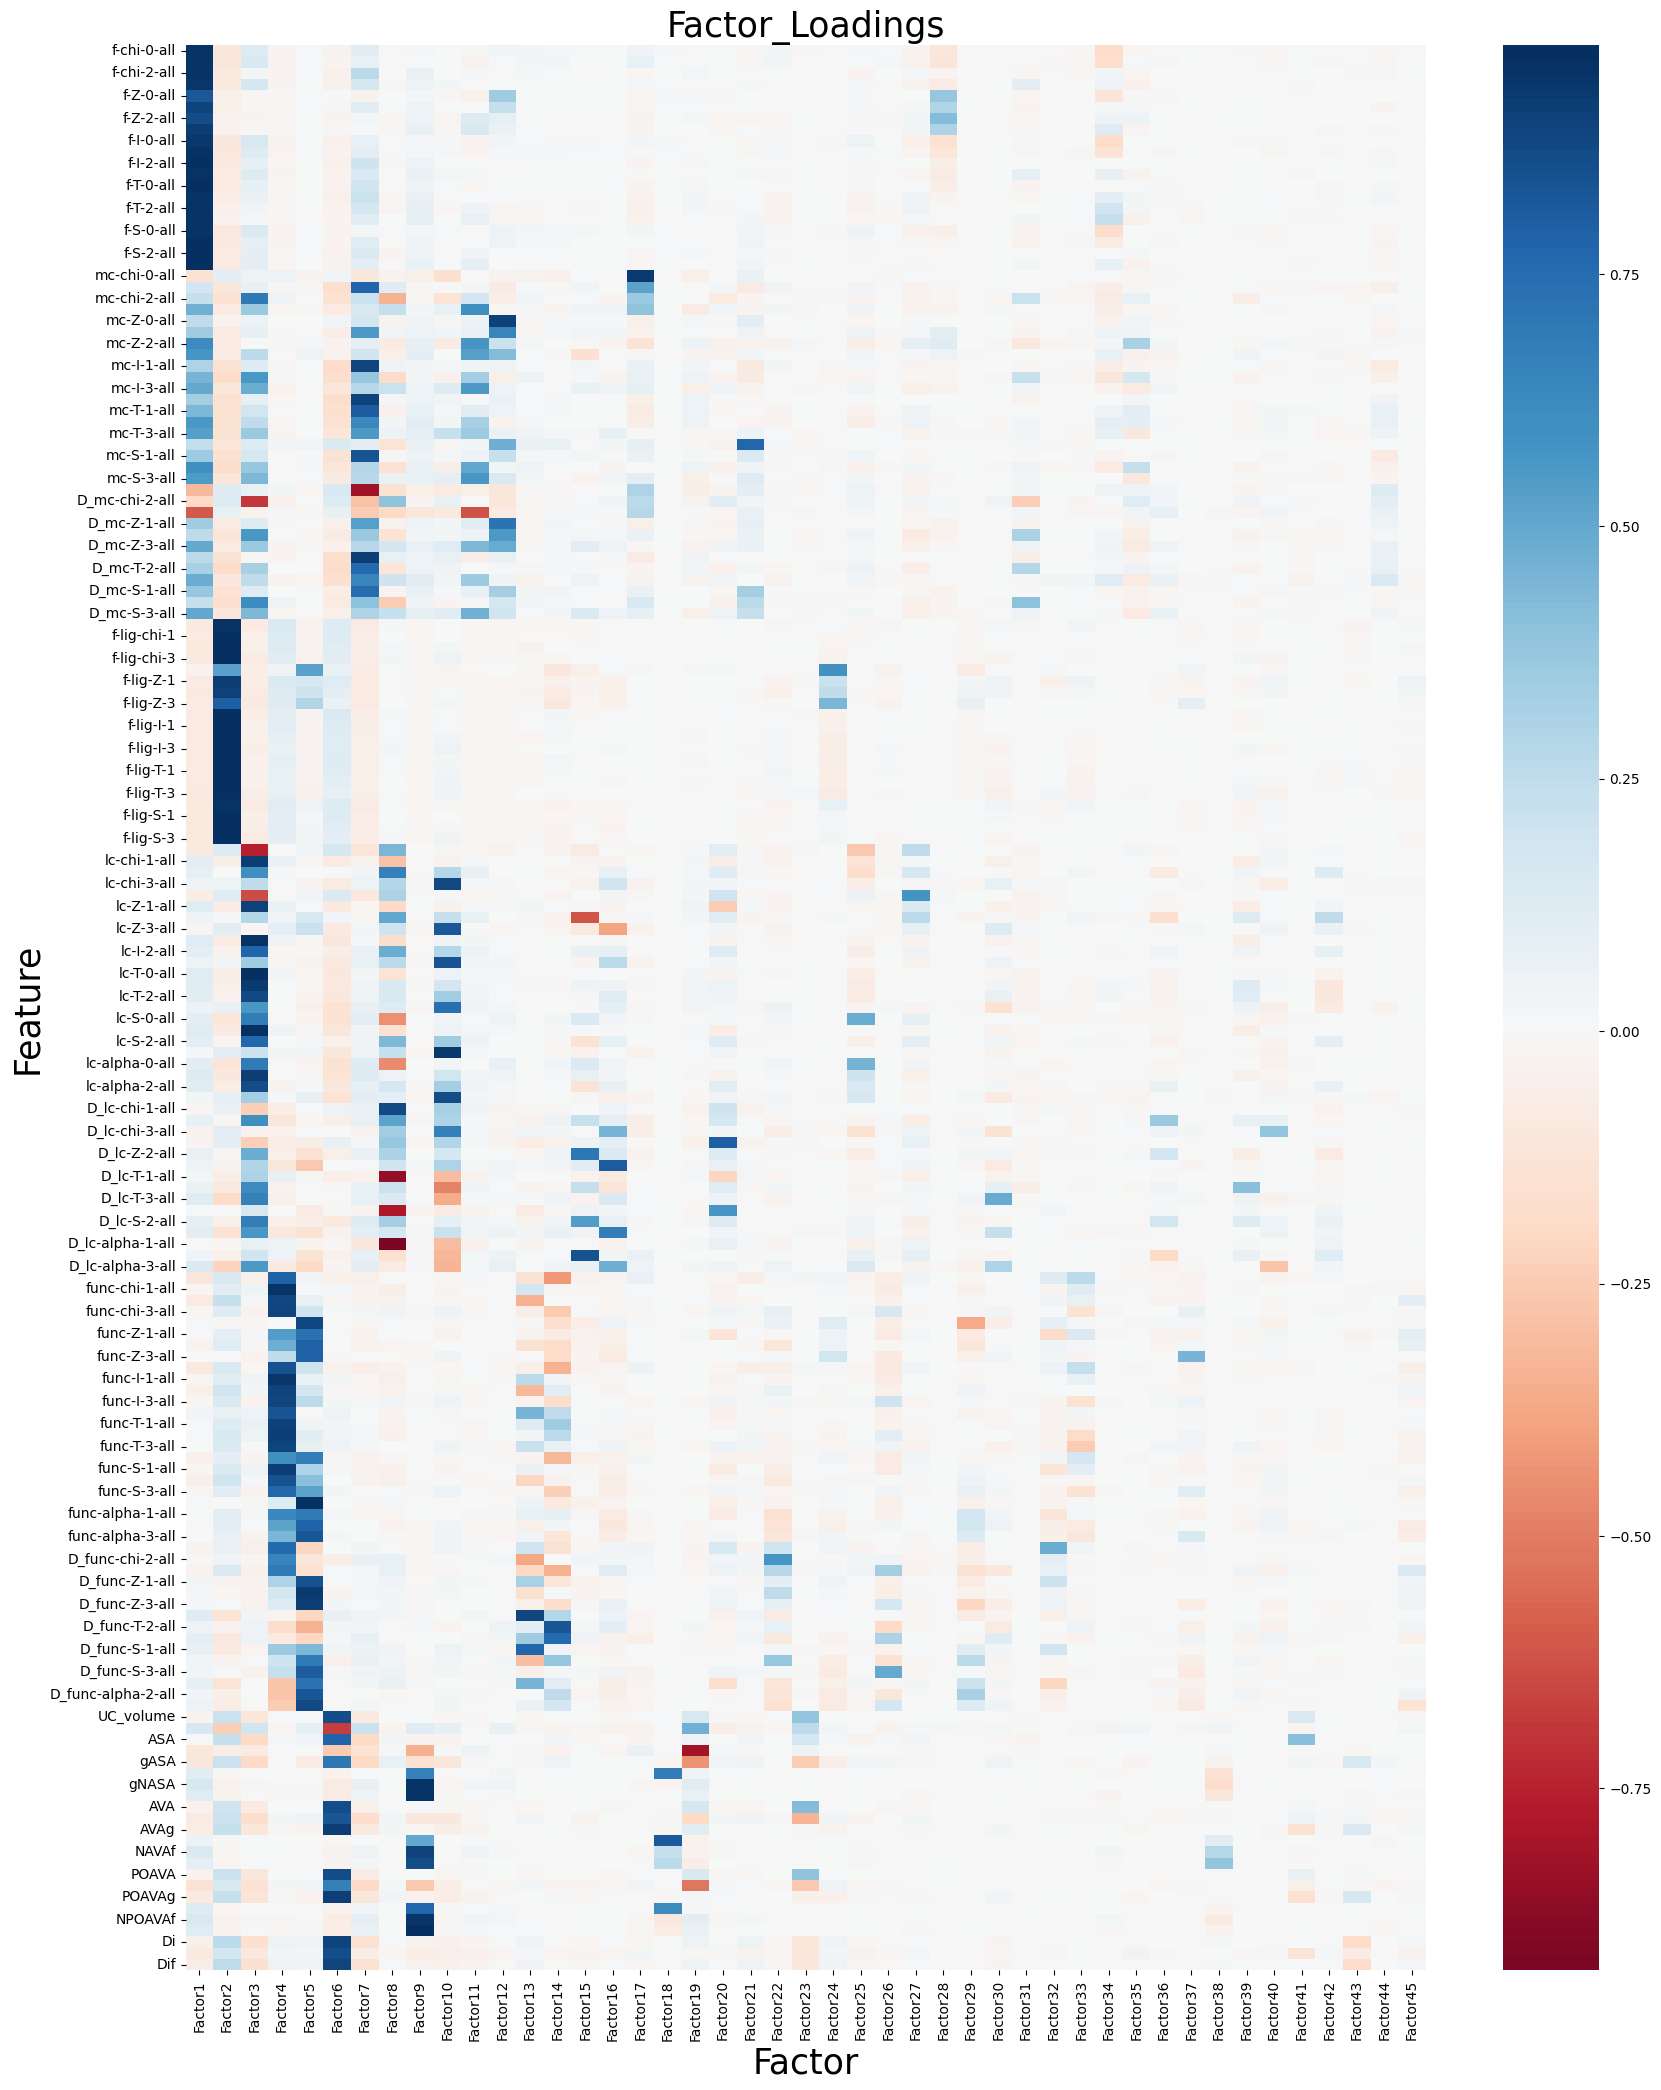

In [199]:
import seaborn as sns
# visualizing factor loadings
plt.figure(figsize=(20, 25))
sns.heatmap(loadings_df, cmap='RdBu', center = 0, annot=False)
plt.title('Factor_Loadings', fontsize=25)
plt.xlabel('Factor', fontsize=25)
plt.ylabel('Feature', fontsize=25)
plt.show()

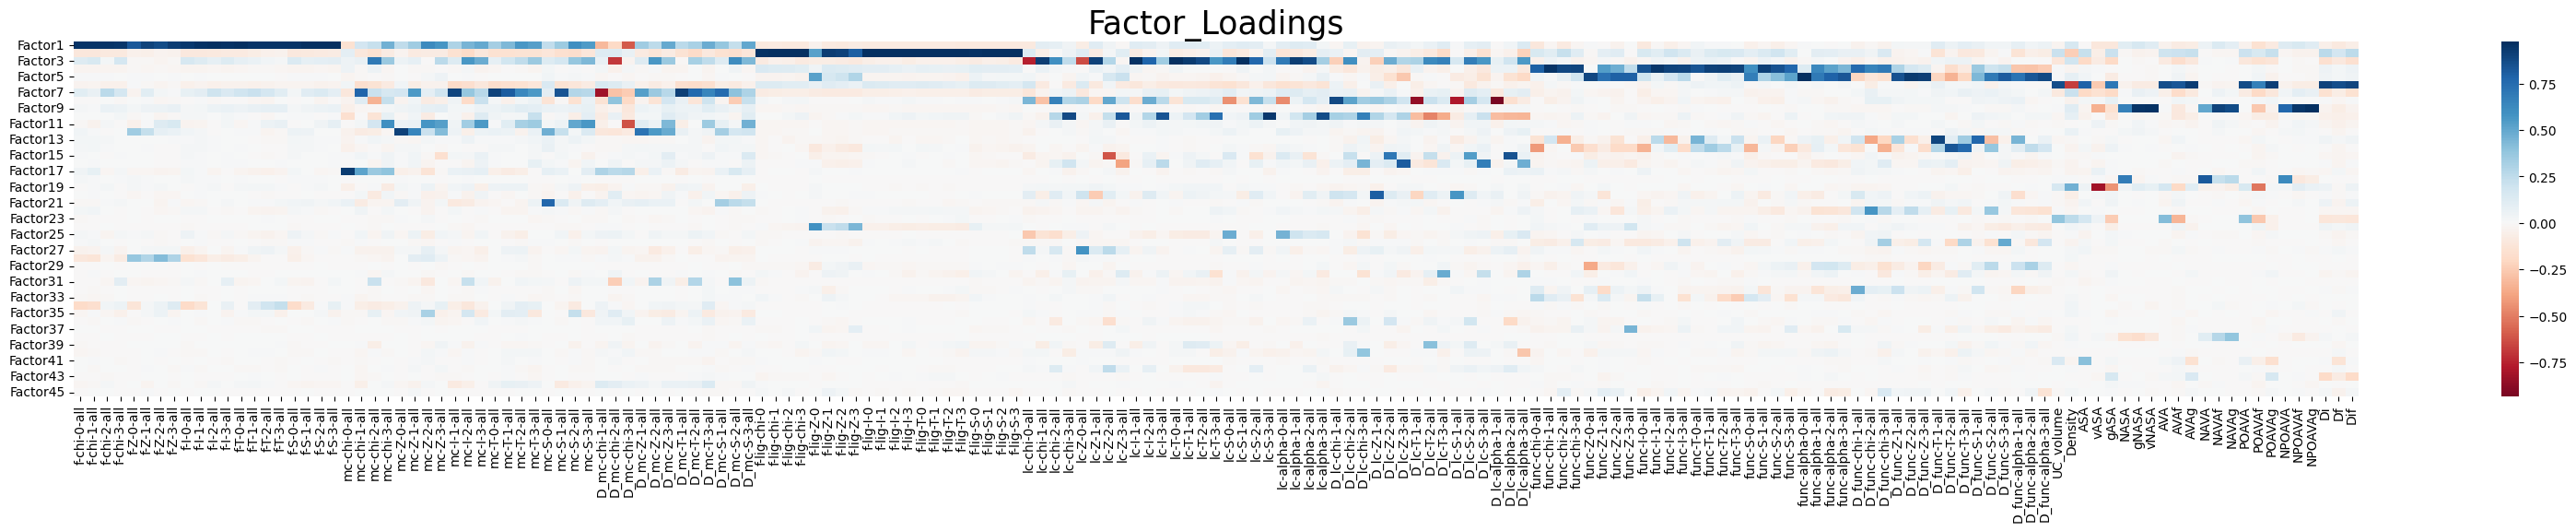

In [200]:
# visualizing factor loadings
plt.figure(figsize=(40, 5))
sns.heatmap(loadings_df.T, cmap='RdBu', center = 0, annot=False)
plt.title('Factor_Loadings', fontsize=25)
plt.show()

In [201]:
framework_desc=[]
mc_desc=[]
lc_desc=[]
func_desc=[]
lig_desc=[]
pore_desc=[]
for descriptor in list(loadings_df.index):
    if 'f-lig' in descriptor:
        lig_desc.append(descriptor)
    elif 'f-' in descriptor:
        framework_desc.append(descriptor)
    elif 'mc-' in descriptor:
        mc_desc.append(descriptor)
    elif 'lc-' in descriptor:
        lc_desc.append(descriptor)
    elif 'func' in descriptor:
        func_desc.append(descriptor)
    else:
        pore_desc.append(descriptor)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
loading_values = (loadings_df.values.T)**2
loading_values = pd.DataFrame(loading_values, columns=loadings_df.index)
categorizing_sum = np.zeros((loadings_df.shape[1],6))
for descriptor in list(loadings_df.index):
    if descriptor in framework_desc:
        categorizing_sum[:,0] += np.abs(loading_values[descriptor])
    elif descriptor in mc_desc:
        categorizing_sum[:,1] += np.abs(loading_values[descriptor])
    elif descriptor in lig_desc:
        categorizing_sum[:,2] += np.abs(loading_values[descriptor])
    elif descriptor in lc_desc:
        categorizing_sum[:,3] += np.abs(loading_values[descriptor])
    elif descriptor in func_desc:
        categorizing_sum[:,4] += np.abs(loading_values[descriptor])
    elif descriptor in pore_desc:
        categorizing_sum[:,5] += np.abs(loading_values[descriptor])

categorized_descriptors = {'framework':framework_desc,
                           'mc':mc_desc,
                           'lig':lig_desc,
                           'lc':lc_desc,
                           'func':func_desc,
                           'pore':pore_desc}

In [203]:
dominant_category = []
dominant_weight = []
for i in range(categorizing_sum.shape[0]):
    dominant_category.append(np.argmax(list(categorizing_sum[i])))
    dominant_weight.append(np.max(list(categorizing_sum[i])))

In [204]:
New_factors = []
for i in range(len(categorized_descriptors)):
    for j in range(45):
        if dominant_category[j] == i:
            New_factors.append(loadings_df.columns[j])

new_factor_loading_df = loadings_df[New_factors]
    

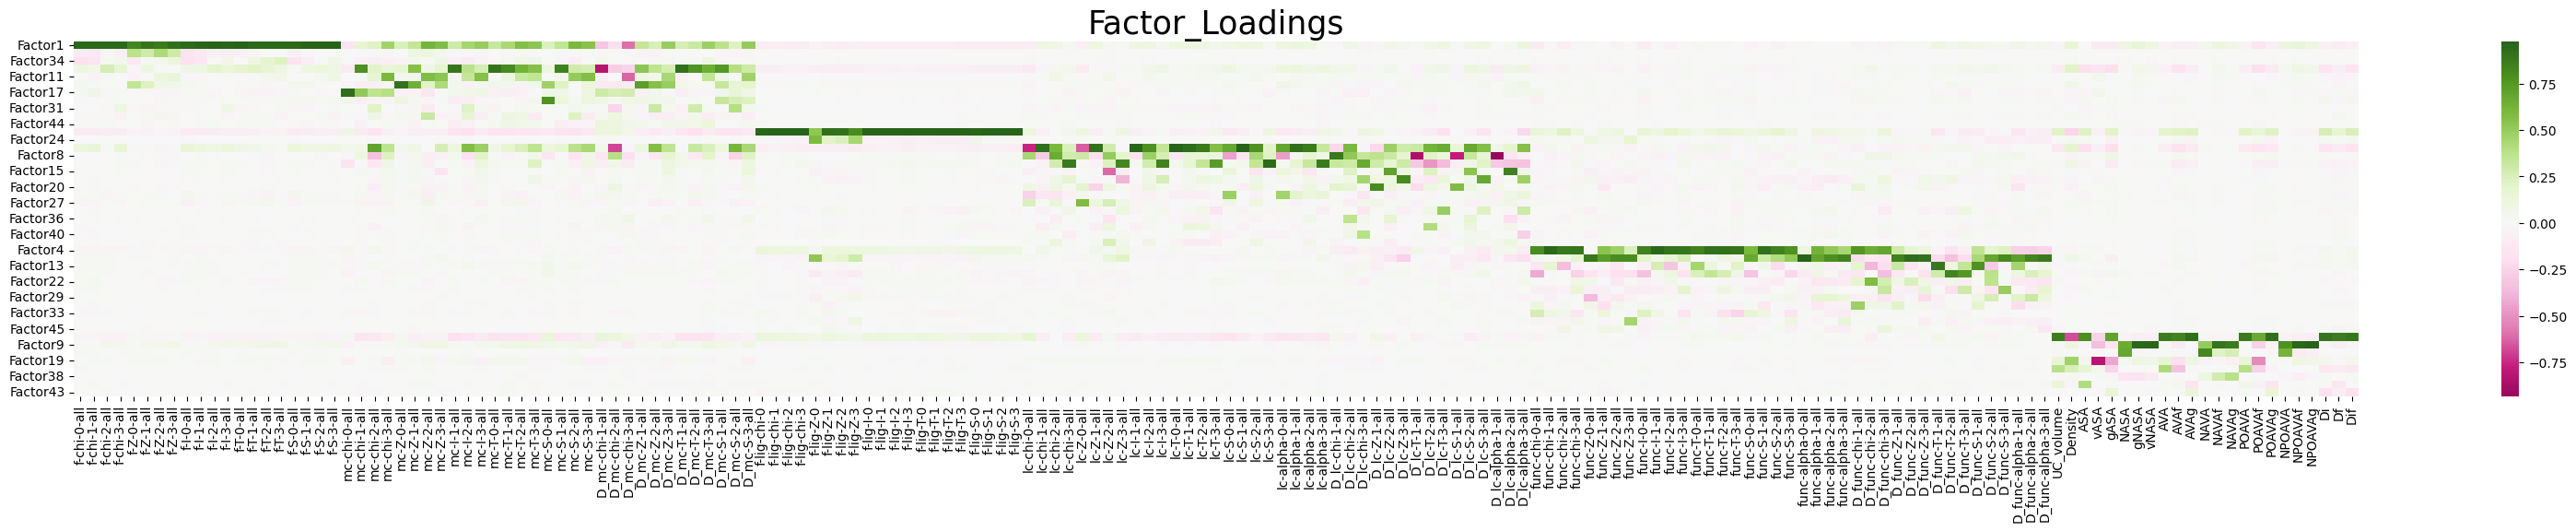

In [205]:
# visualizing factor loadings
from matplotlib.colors import LinearSegmentedColormap

plt.figure(figsize=(40, 5))
sns.heatmap(new_factor_loading_df.T, cmap='PiYG', center = 0, annot=False)
plt.title('Factor_Loadings', fontsize=25)
plt.show()

In [ ]:
scaler = MinMaxScaler()
categorizing_sum = scaler.fit_transform(categorizing_sum.T).T
categorizing_sum = pd.DataFrame(categorizing_sum, columns=['framework','mc','lc','func','lig','pore'],index=loadings_df.columns)

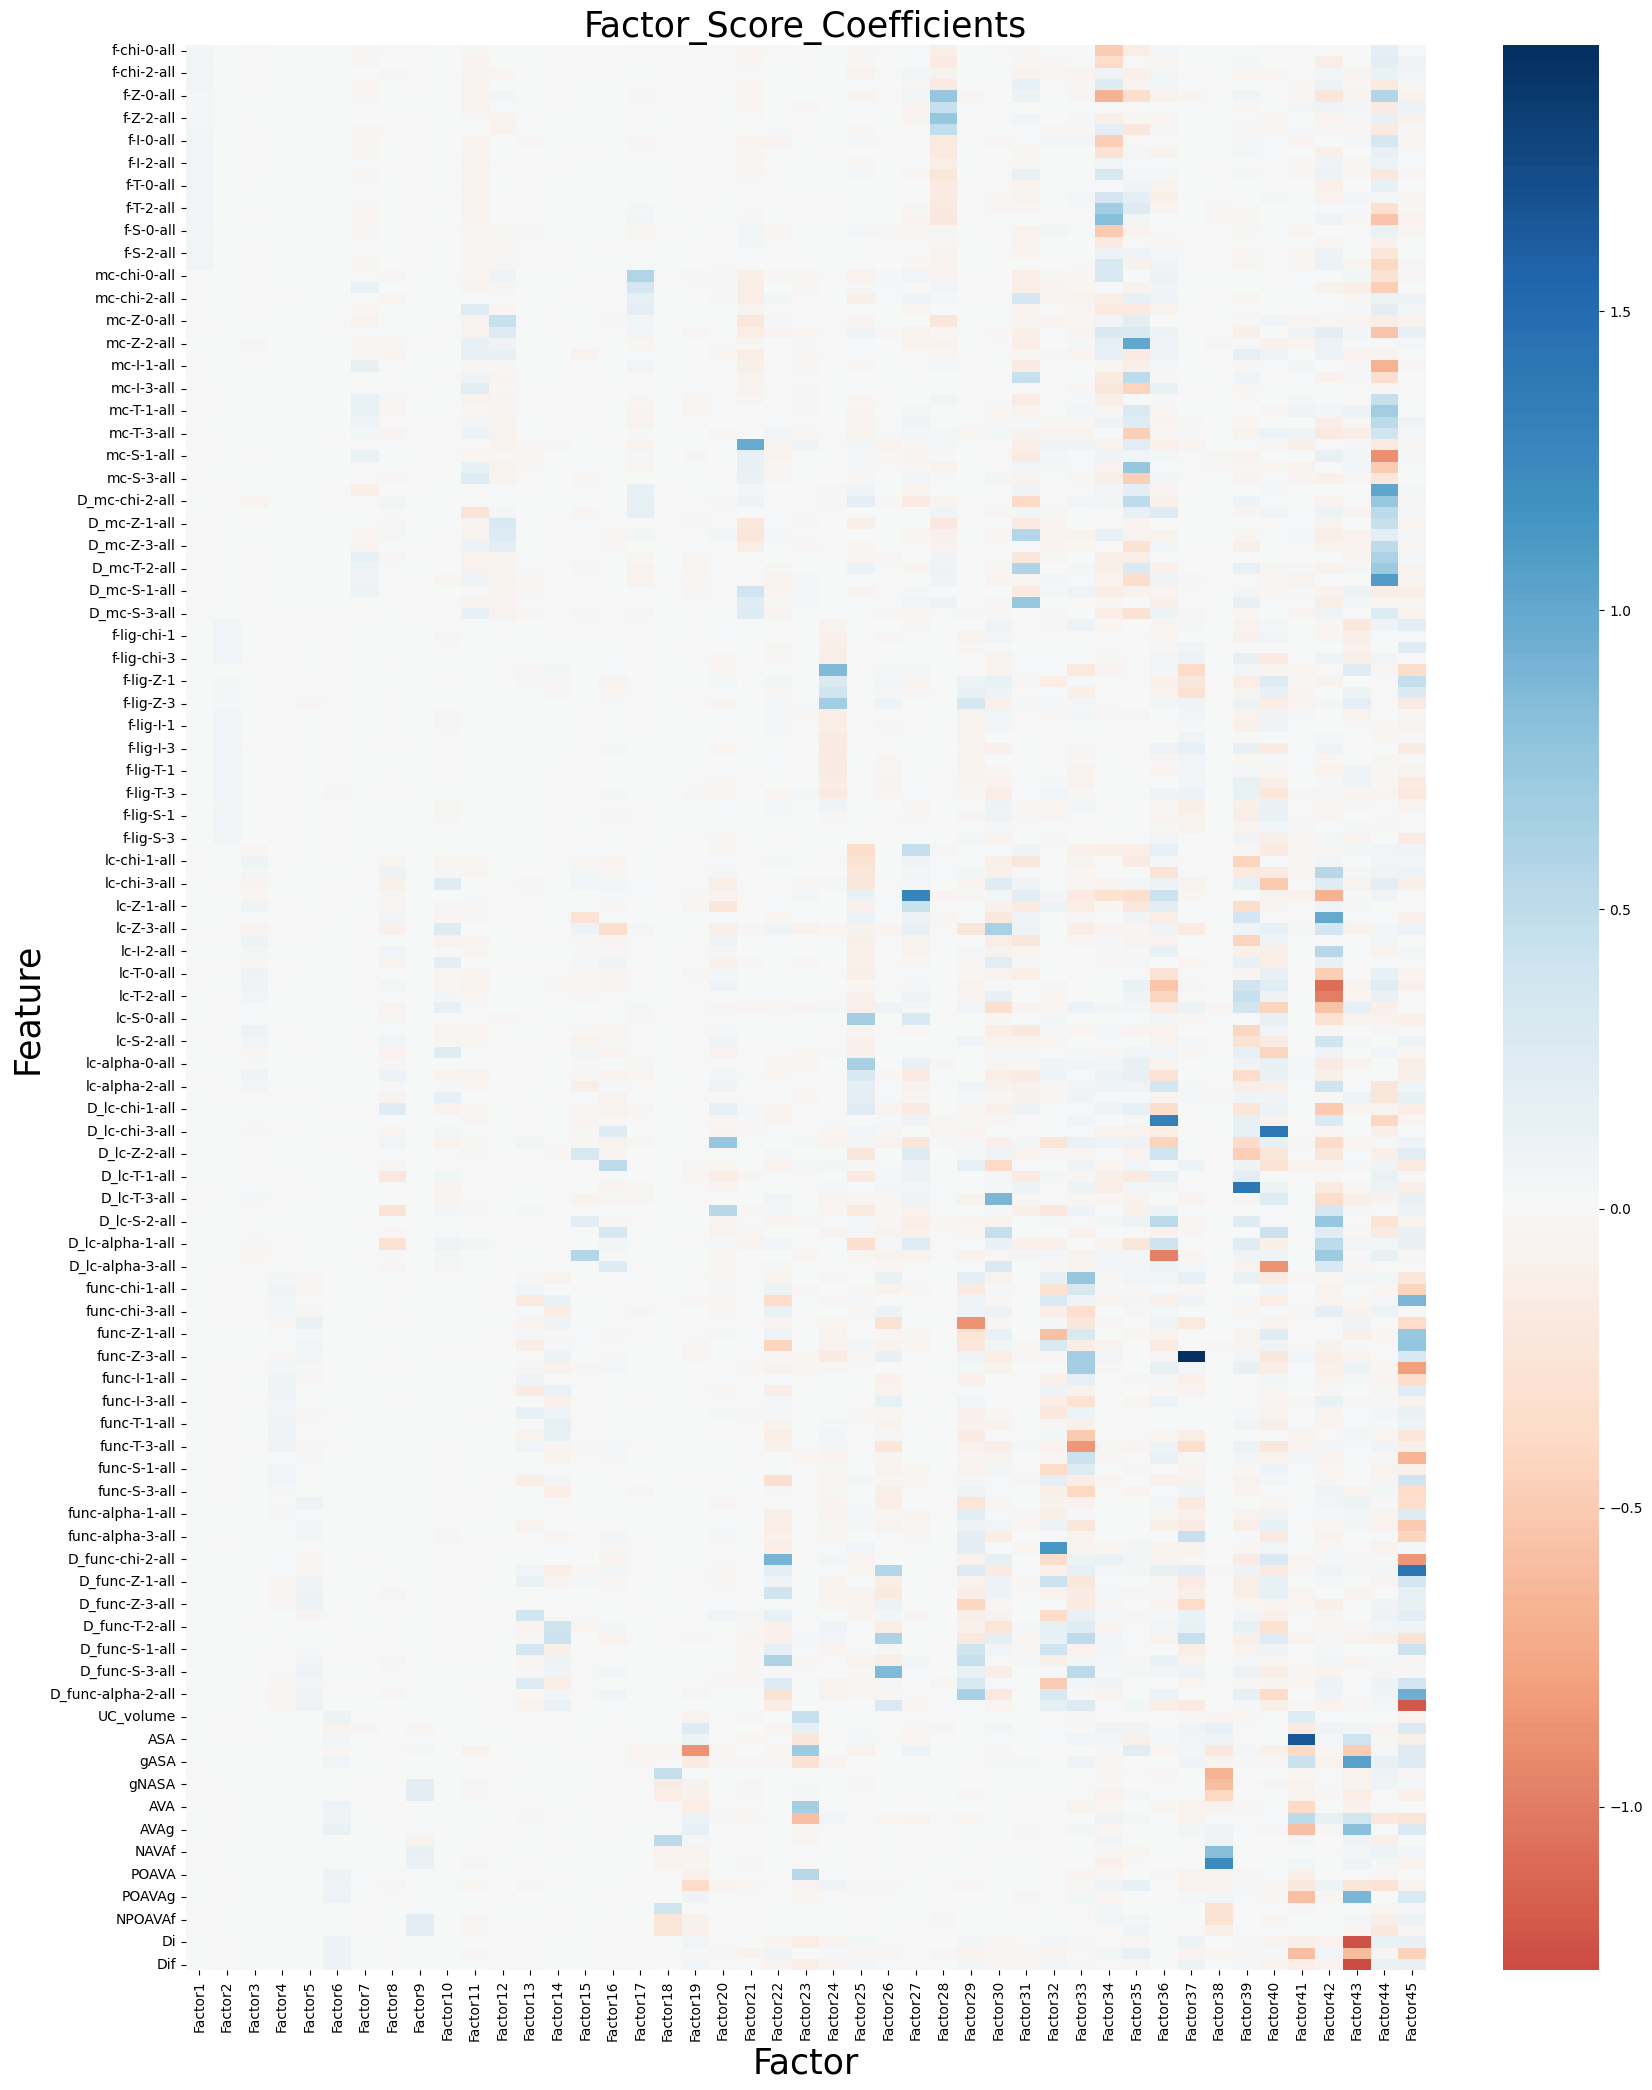

In [206]:
import seaborn as sns
# visualizing factor loadings
plt.figure(figsize=(20, 25))
sns.heatmap(factor_score_coefficients_df, cmap='RdBu', center = 0, annot=False)
plt.title('Factor_Score_Coefficients', fontsize=25)
plt.xlabel('Factor', fontsize=25)
plt.ylabel('Feature', fontsize=25)
plt.show()

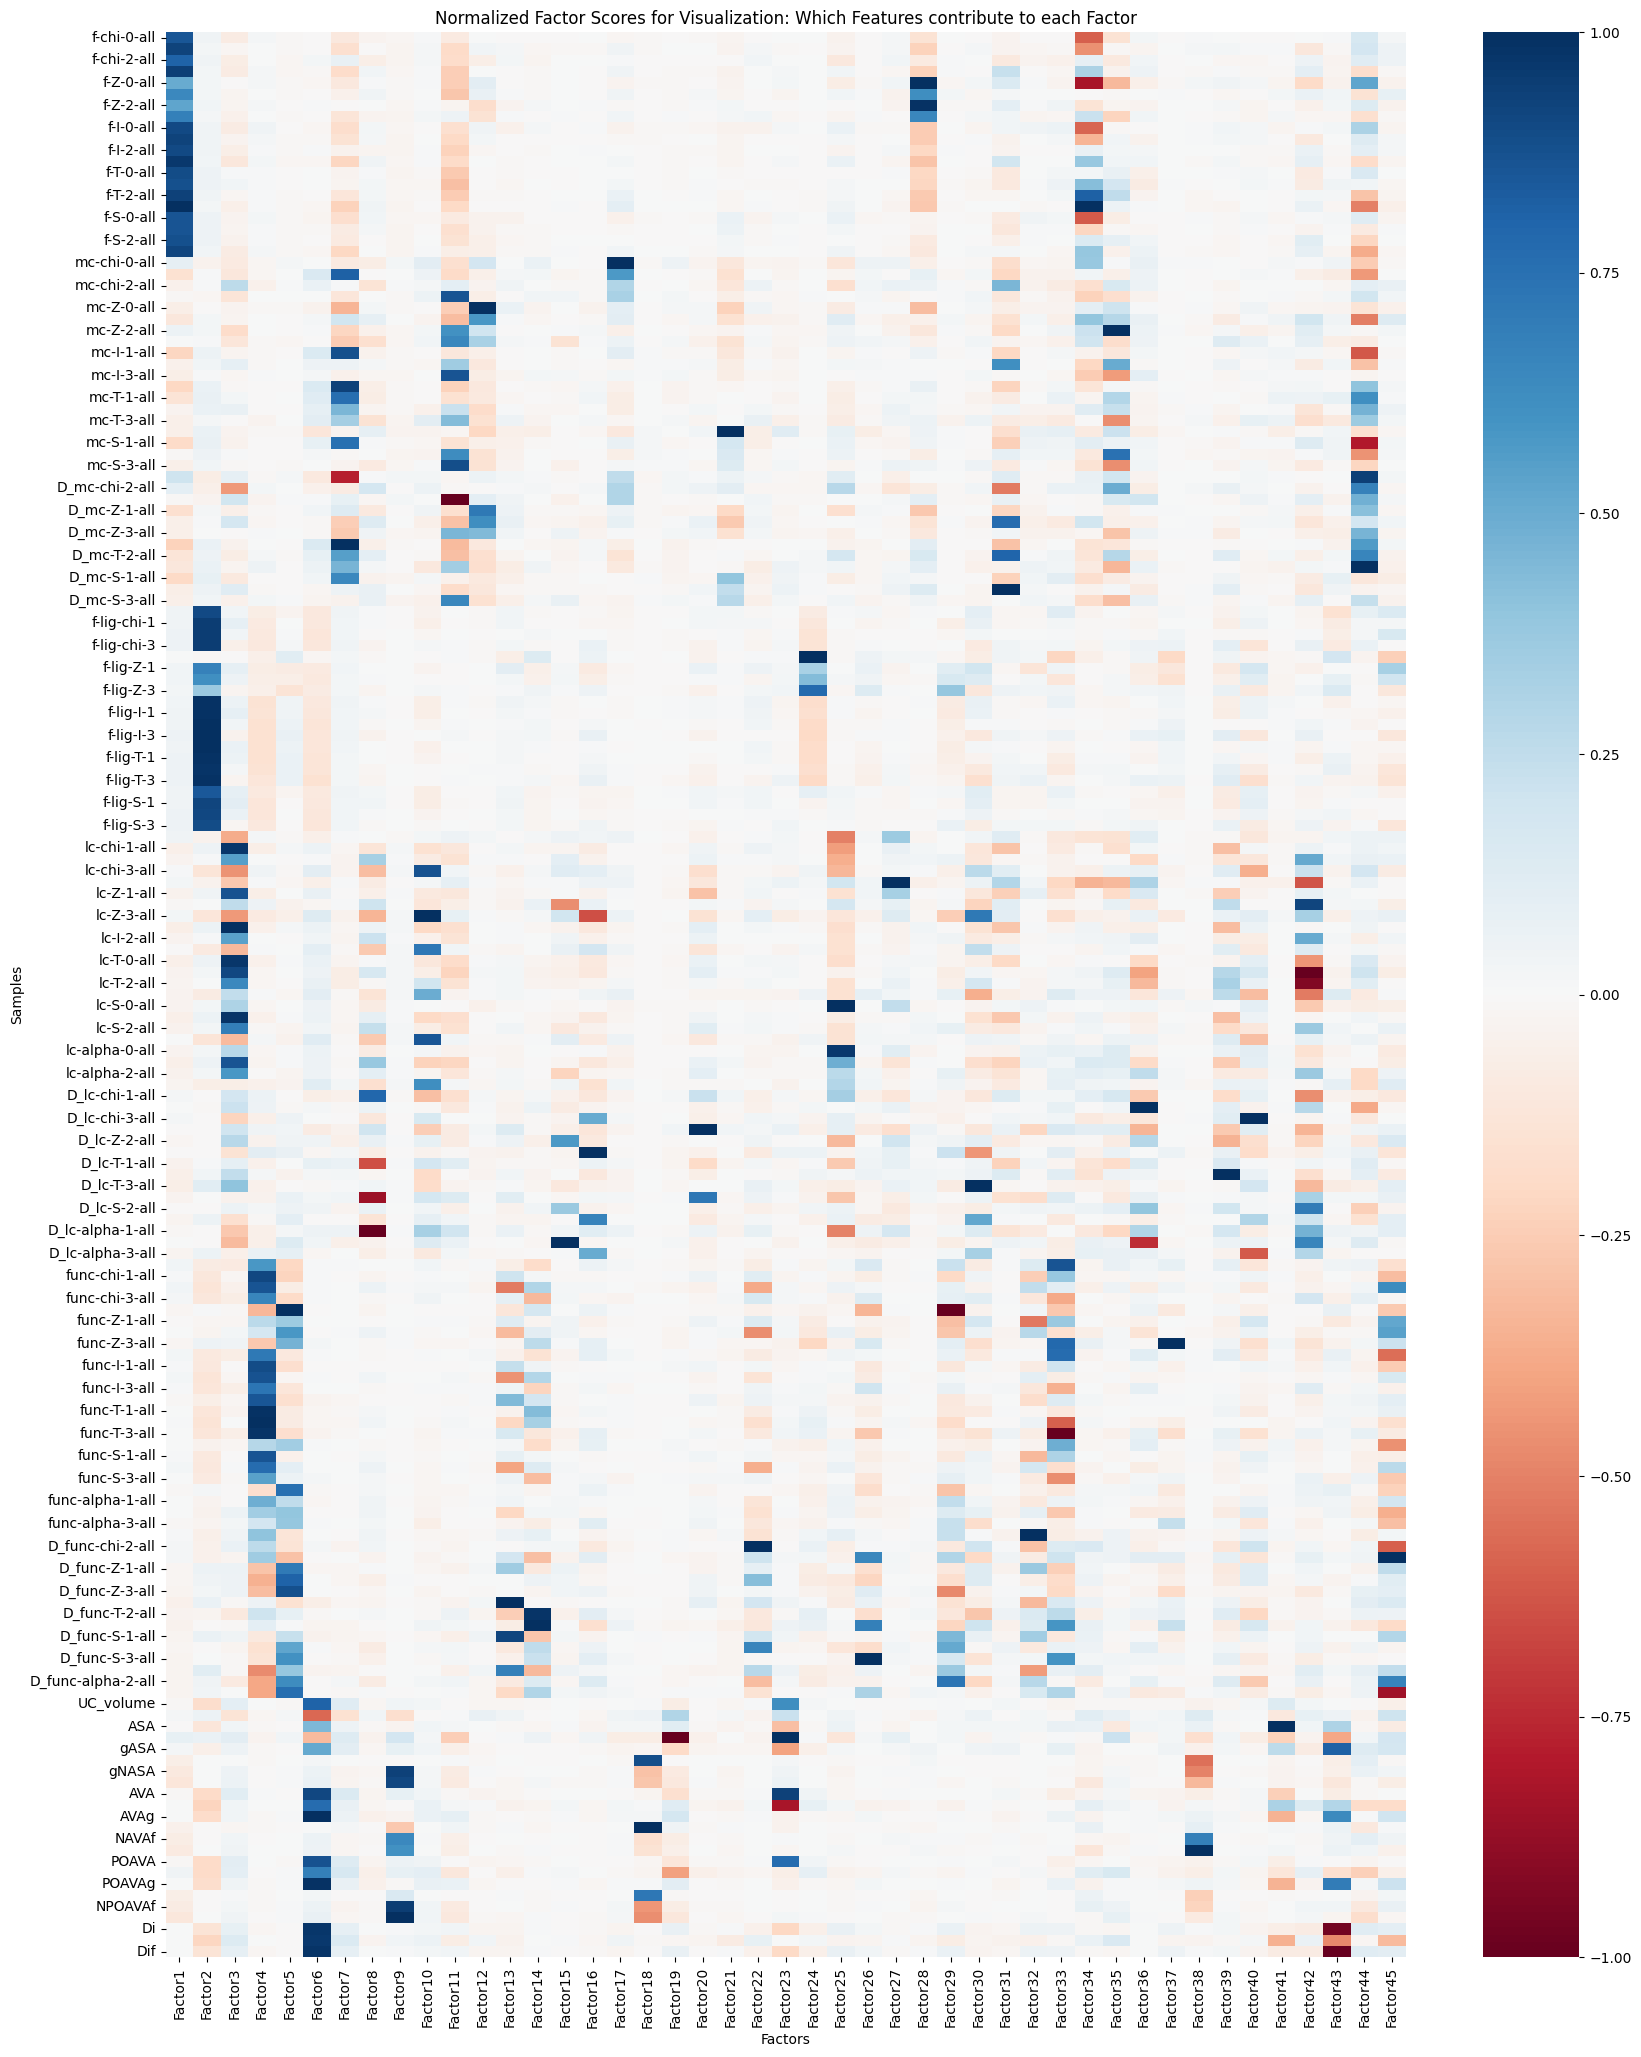

In [207]:
# Step 1: Normalize each column by dividing by the maximum absolute value in each column
normalized_factor_scores_df = factor_score_coefficients_df.apply(lambda x: x / np.max(np.abs(x)), axis=0)

# Step 2: Display the normalized DataFrame
# Visualizing the normalized factor scores

plt.figure(figsize=(20, 25))
sns.heatmap(normalized_factor_scores_df, cmap='RdBu', center=0, annot=False)
plt.title('Normalized Factor Scores for Visualization: Which Features contribute to each Factor')
plt.xlabel('Factors')
plt.ylabel('Samples')
plt.show()

In [208]:
# Now, to apply the transformation to other feature matrices
factor_scores_df = df_standardized.values @ factor_score_coefficients.T              #all MOFs
factor_scores_dfX = dfX_standardized.values @ factor_score_coefficients.T              #MOFs used in this study
factor_scores_dfEMOF = dfEMOF_standardized.values @ factor_score_coefficients.T         #experimentally available MOFs
# Convert the factor scores to a DataFrame for easier handling, with appropriate column names
factor_scores_df = pd.DataFrame(factor_scores_df, columns=[f'Factor{i+1}' for i in range(fa.n_factors)])
factor_scores_dfX = pd.DataFrame(factor_scores_dfX, columns=[f'Factor{i+1}' for i in range(fa.n_factors)], index = MOF_index.values)
factor_scores_dfEMOF = pd.DataFrame(factor_scores_dfEMOF, columns=[f'Factor{i+1}' for i in range(fa.n_factors)])

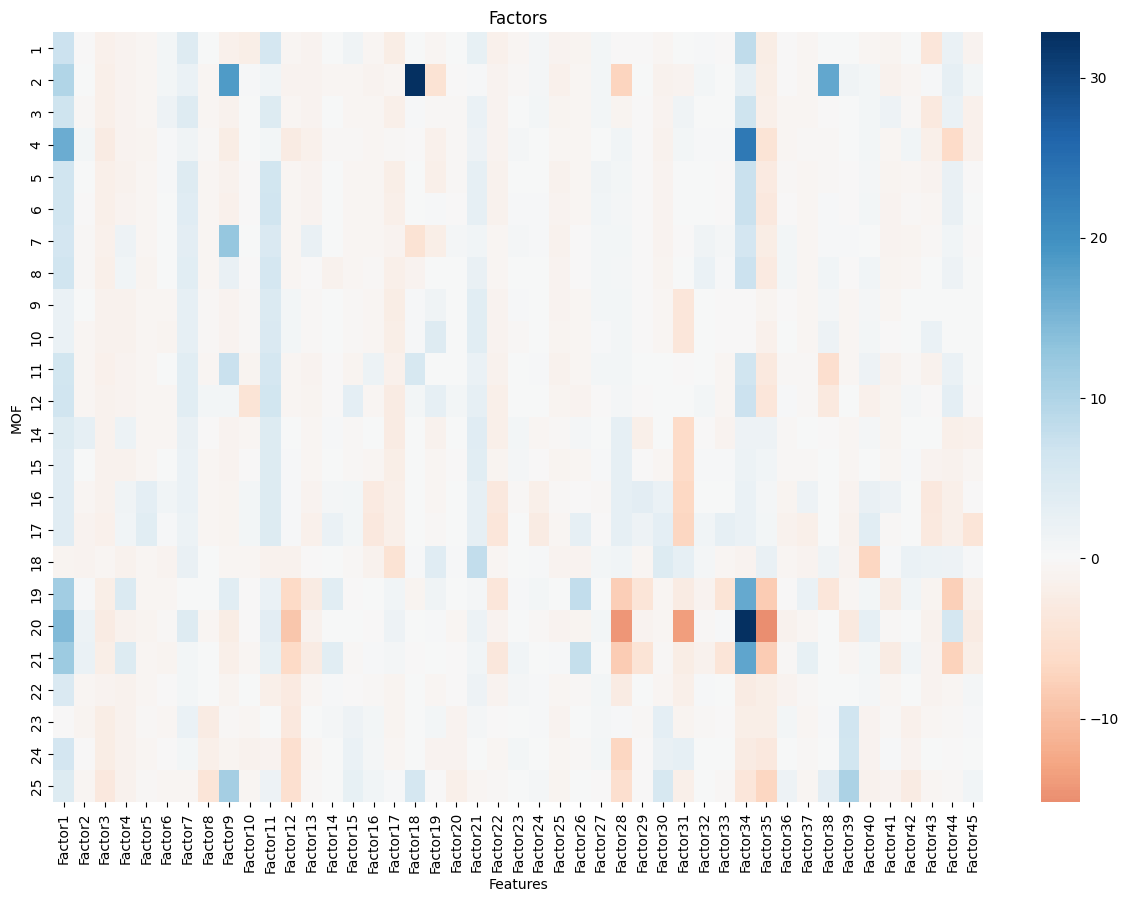

In [209]:
# feature visualization
plt.figure(figsize=(15, 10))
sns.heatmap(factor_scores_dfX, cmap='RdBu', center = 0, annot=False)
plt.title('Factors')
plt.xlabel('Features')
plt.ylabel('MOF')
plt.show()

In [210]:
print(df_standardized.shape)
print(dfX_standardized.shape)
print(factor_score_coefficients.T.shape)

(472494, 171)
(24, 171)
(171, 45)


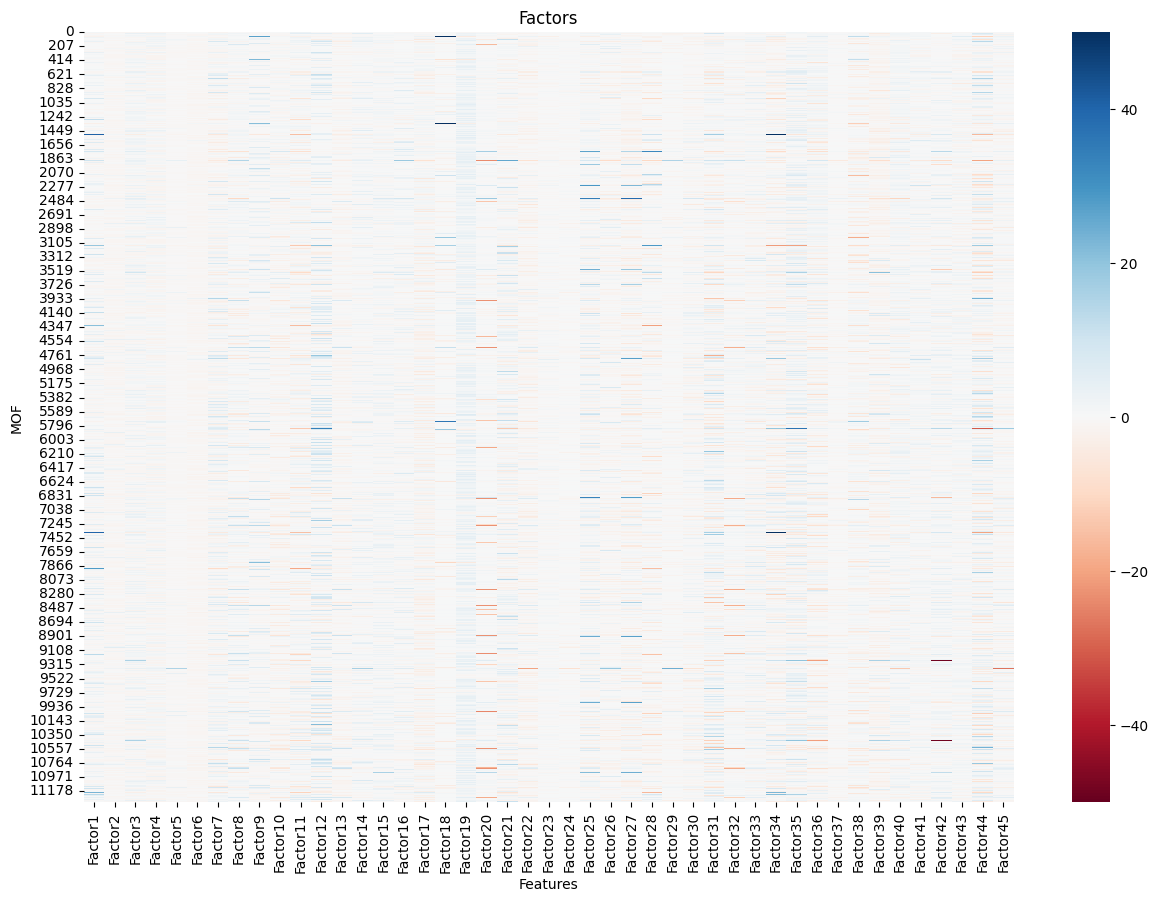

In [211]:
# EMOF visualization
plt.figure(figsize=(15, 10))
sns.heatmap(factor_scores_dfEMOF, cmap='RdBu', center = 0, annot=False, vmin=-50, vmax=50)
plt.title('Factors')
plt.xlabel('Features')
plt.ylabel('MOF')
plt.show()

In [258]:
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer
import pandas as pd

# Assuming `df` is your DataFrame with the data to be analyzed

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data to standardize it

standardized_allMOF = scaler.fit_transform(factor_scores_df)
standardized_allMOF = pd.DataFrame(standardized_allMOF, columns=factor_scores_df.columns)     #all MOFs

standardized_data = scaler.fit_transform(factor_scores_dfX)
standardized_data = pd.DataFrame(standardized_data, columns=factor_scores_dfX.columns)     #MOFs used in this study

# transformation_matrix = np.linalg.pinv(factor_scores_dfX_removestd_2)@standardized_data
standardized_EMOF = scaler.transform(factor_scores_dfEMOF)
standardized_EMOF = pd.DataFrame(standardized_EMOF, columns=factor_scores_dfX.columns)     # for MOFs experimentally available


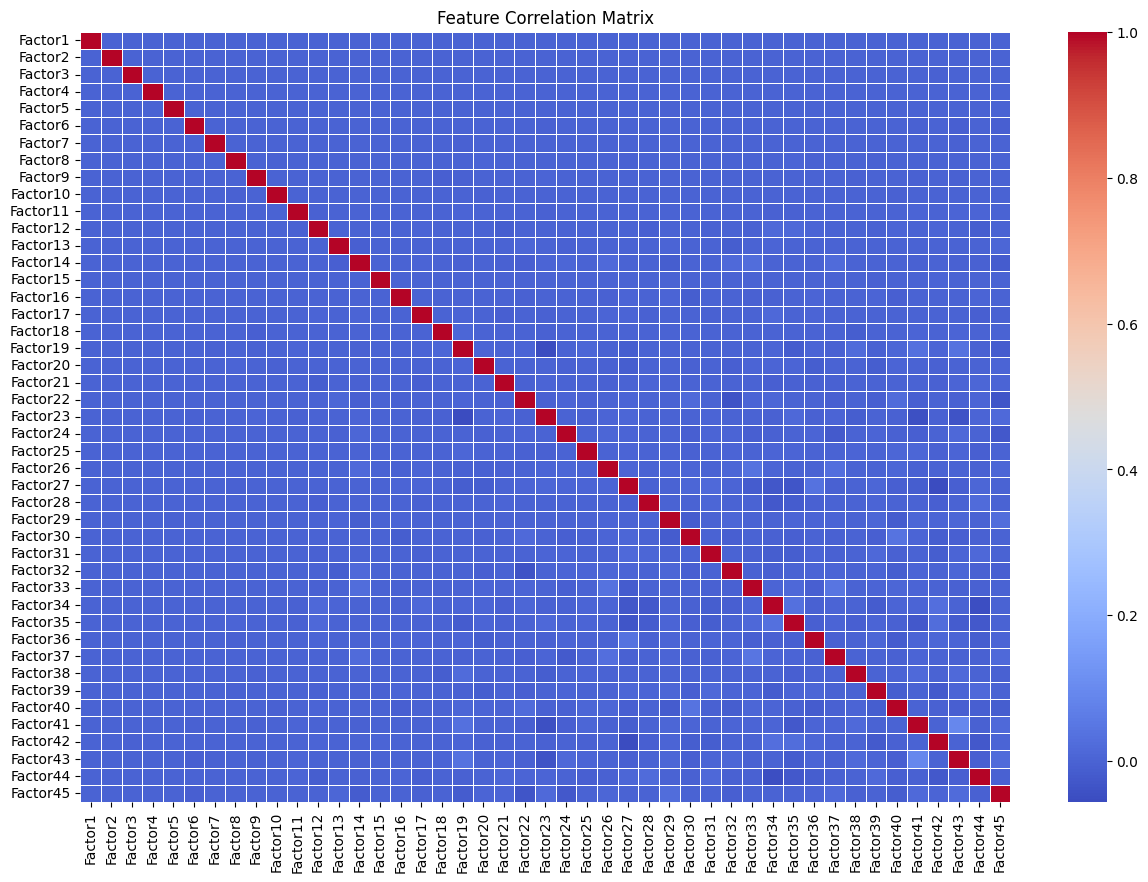

In [259]:
#check for correlation in these parameters
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame containing the 14 data points and 55 features

# Calculate the correlation matrix
corr_matrix = standardized_allMOF.corr()

# Visualize the correlation matrix
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', linewidths=0.5, annot=False)
plt.title('Feature Correlation Matrix')
plt.show()


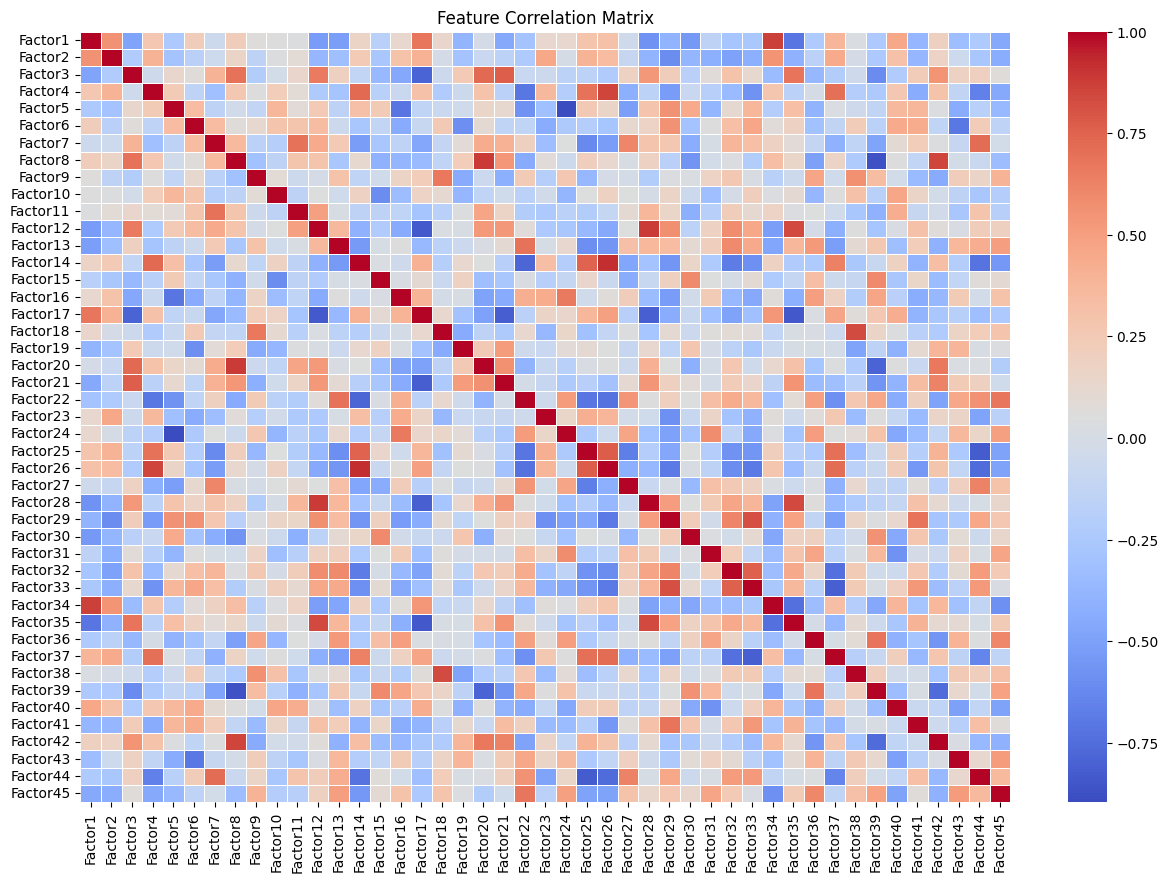

In [260]:
#check for correlation in these parameters

# Assuming 'df' is your DataFrame containing the 14 data points and 55 features

# Calculate the correlation matrix
corr_matrix = standardized_data.corr()

# Visualize the correlation matrix
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', linewidths=0.5, annot=False)
plt.title('Feature Correlation Matrix')
plt.show()


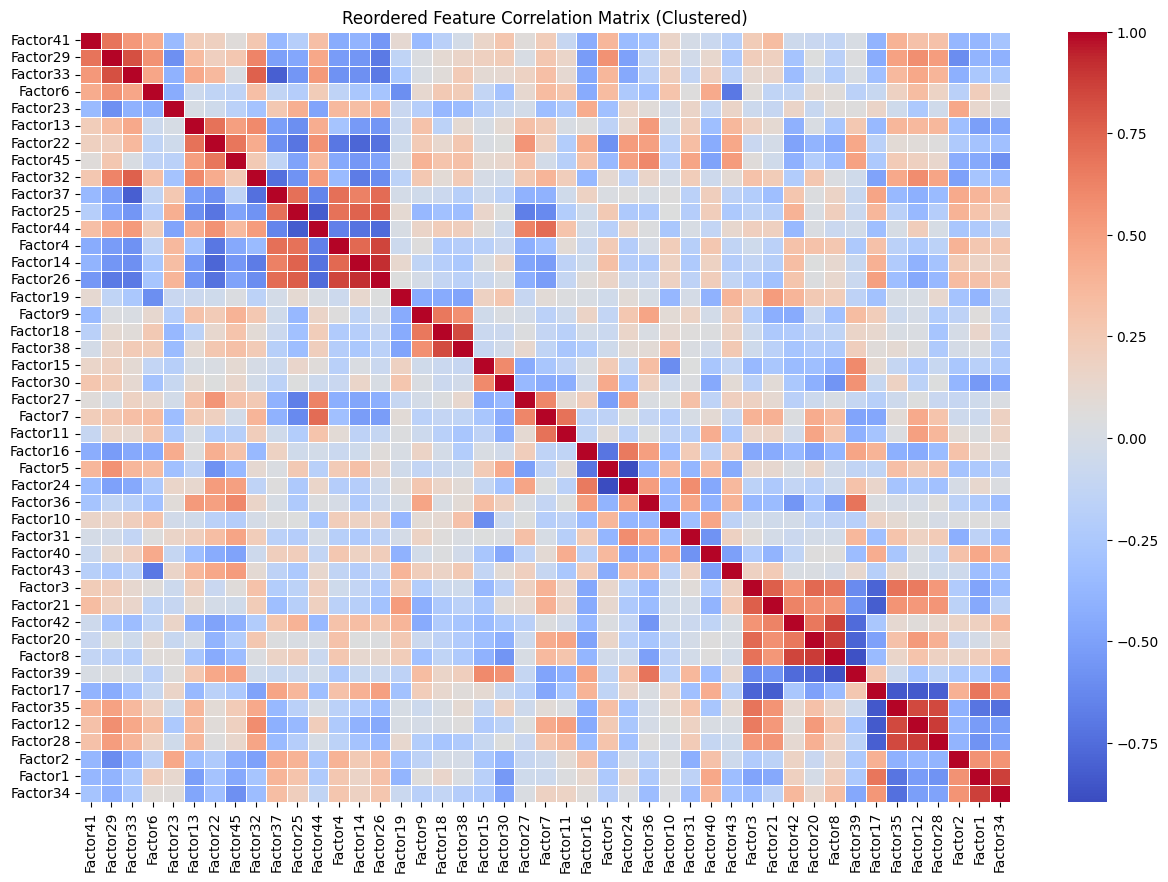

In [261]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list

# Assuming 'standardized_data' is your DataFrame containing standardized features

# Step 1: Calculate the correlation matrix
corr_matrix = standardized_data.corr()

# Step 2: Reorder correlation matrix to cluster positive and negative correlations together
# Perform hierarchical clustering on correlation matrix
linkage_matrix = linkage(np.abs(corr_matrix), method='ward')
ordered_indices = leaves_list(linkage_matrix)

# Reorder the correlation matrix
df_reordered = corr_matrix.iloc[ordered_indices, ordered_indices]

# Step 3: Visualize the reordered correlation matrix
plt.figure(figsize=(15, 10))
sns.heatmap(df_reordered, cmap='coolwarm', linewidths=0.5, annot=False)
plt.title('Reordered Feature Correlation Matrix (Clustered)')
plt.show()


In [216]:
reordered_standardized_data = standardized_data.iloc[:,ordered_indices]
reordered_standardized_data

,Factor41,Factor29,Factor33,Factor6,Factor23,Factor13,Factor22,Factor45,Factor32,Factor37,...,Factor20,Factor8,Factor39,Factor17,Factor35,Factor12,Factor28,Factor2,Factor1,Factor34
0,-0.841586,-0.048647,-0.107381,0.885388,-0.394704,-1.053036,-1.589204,-0.842110,0.519653,-0.547931,...,0.200519,0.131547,0.037756,-2.408089,-2.252091,-0.658086,-0.180780,-0.047647,7.066433,7.996736
1,-1.275048,0.180475,0.330312,0.965289,-0.297006,-1.144971,-0.937368,0.796051,0.792681,-0.404021,...,-0.200714,-0.719553,1.353505,-0.554442,-2.087779,-1.196356,-7.055198,0.184587,9.892610,3.063189
2,1.661432,-0.044340,0.049898,1.539502,0.244783,-1.080526,-1.277152,-1.415091,0.284985,-0.708131,...,-0.229186,-0.521857,0.309687,-1.920754,-1.788745,-0.397736,-0.826725,-0.222552,6.900561,6.592011
3,-0.489791,-0.182208,0.428742,0.357330,0.622639,-1.542295,-1.260103,-1.467000,0.355167,-0.257318,...,-0.267024,-0.241777,0.097963,-0.269850,-4.233870,-2.443256,1.185002,0.739039,16.138307,22.839136
4,-0.757507,-0.151523,-0.021752,0.433093,0.332589,-0.964274,-1.385309,-0.048153,0.224444,-0.423927,...,-0.238529,-0.635340,-0.044310,-2.202810,-2.786876,-0.625871,0.756936,0.309692,6.706625,7.050824
5,-0.901019,-0.105427,-0.195371,-0.015746,0.401921,-0.979039,-1.452884,0.017340,0.201702,-0.566655,...,-0.065613,-0.549285,-0.181890,-2.060287,-3.264618,-0.548908,0.706833,-0.170227,6.667976,7.116065
6,-1.025763,-0.198356,0.612054,0.236753,0.546823,2.522027,-0.563311,-0.156306,1.339631,-0.603100,...,0.701356,-0.600202,0.456536,-1.233406,-2.219113,-0.469641,0.730275,-0.308690,6.100376,5.820531
7,-0.715077,-0.122655,0.415078,0.016060,0.299749,-0.094095,-0.509533,0.292973,2.020855,-0.600079,...,0.125547,-0.447698,-0.079958,-1.950182,-2.886941,-0.520233,0.651186,-0.359842,6.546990,6.743034
8,-0.699211,-0.093783,-0.066755,-0.561969,0.496021,-0.366477,-0.982660,0.060414,0.273333,-0.423964,...,0.095582,-0.352330,-0.558702,-2.393314,-0.868865,0.901852,1.060357,0.008752,2.410490,-0.165185
9,-0.120059,-0.030395,-0.165407,-0.832092,-0.346611,-0.390337,-1.053067,0.232897,0.297474,-0.495651,...,0.275145,-0.263790,-0.688425,-2.218637,-1.498602,0.977291,1.018381,-0.489847,2.368792,-0.078210


In [223]:
dfNi = pd.read_csv('./20_MOFs_Ni_new.csv')

In [224]:
dfNi

,MOF_index,MOF,Yield_mean,Selectivity_mean,Yield_1,Yield_2,Selectivity_1,Selectivity_2,Structure_integrity_after_rxn,Ni_M_ratio
0,1,MOF-808,0.8850,0.9780,0.890,0.880,0.972,0.984,1,0.510
1,2,MOF-808-BA,0.1400,0.9990,0.150,0.130,0.998,1.000,1,0.510
2,3,MOF-808-W,0.7400,0.7890,0.770,0.710,0.770,0.808,1,0.510
3,4,Zr12-BPDC,0.7000,0.6800,0.720,0.680,0.678,0.682,1,0.270
4,5,UiO-67,0.5350,0.6335,0.600,0.470,0.663,0.604,1,0.230
5,6,UiO-66,0.5400,0.8480,0.550,0.530,0.857,0.839,1,0.100
6,7,UiO-66-NH2,0.4500,0.8840,0.490,0.410,0.870,0.898,1,0.100
7,8,UiO-66-OH,0.4000,0.8765,0.410,0.390,0.898,0.855,1,0.100
8,9,MIL-140-BPDC,0.0600,0.7490,0.070,0.050,0.797,0.701,1,0.510
9,10,MIL-140-BDC,0.0600,0.0520,0.070,0.050,0.023,0.081,1,0.060


d:\Anaconda3\envs\rdkit\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
d:\Anaconda3\envs\rdkit\lib\site-packages\sklearn\manifold\_spectral_embedding.py:301: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


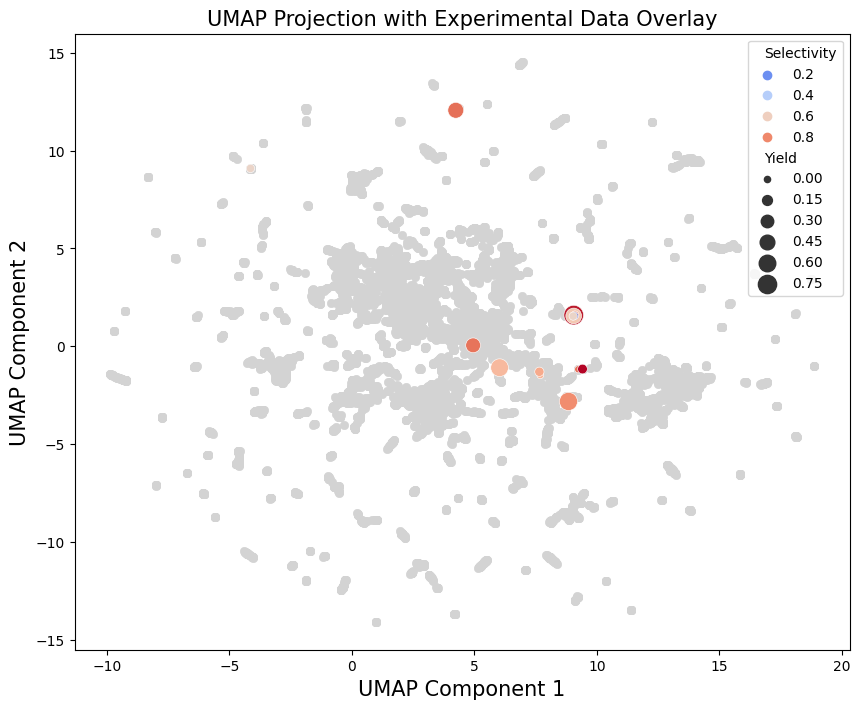

In [219]:
import os
from sklearn.manifold import TSNE
import umap

# Apply tSNE for dimensionality reduction and visualization
tsne = TSNE(n_components=2, perplexity=30, n_iter=300, random_state=42)
tsne_results = tsne.fit_transform(standardized_EMOF)

# Apply UMAP for an alternative visualization
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_results = reducer.fit_transform(standardized_EMOF)

# Convert the results into a DataFrame and add the metal type information
df_tsne = pd.DataFrame(tsne_results, columns=['tSNE1', 'tSNE2'])
# df_tsne['Metal'] = filtered_mofs_df['Metal']

df_umap = pd.DataFrame(umap_results, columns=['UMAP1', 'UMAP2'])
# df_umap['Metal'] = filtered_mofs_df['Metal']

# Overlaying experimental data onto the UMAP plot
dfX_umap = reducer.transform(standardized_data)
dfX_umap = pd.DataFrame(dfX_umap, columns=['UMAP1', 'UMAP2'])
dfX_umap['Yield'] = dfNi['Yield_mean']  # Example: replace with actual yield data
dfX_umap['Selectivity'] = dfNi['Selectivity_mean']  # Example: replace with actual selectivity data

# Visualize UMAP results with different colors
plt.figure(figsize=(10, 8))
sns.scatterplot(x='UMAP1', y='UMAP2', data=df_umap, legend=None, color='lightgrey', edgecolor=None)
sns.scatterplot(x='UMAP1', y='UMAP2', hue='Selectivity', size='Yield', data=dfX_umap, palette='coolwarm', sizes=(20, 200))
plt.xlabel('UMAP Component 1',fontsize=15)
plt.ylabel('UMAP Component 2',fontsize=15)
plt.title('UMAP Projection with Experimental Data Overlay',fontsize=15)
plt.show()

Trial: 0
Model: LogisticRegression
Selected Features: ['Factor4', 'Factor6', 'Factor11', 'Factor15', 'Factor19', 'Factor22', 'Factor25', 'Factor27', 'Factor30', 'Factor34']
Test Accuracy: 1.0
Test F1 Score: 1.0
Model: DecisionTree
Selected Features: ['Factor14', 'Factor15', 'Factor16', 'Factor17', 'Factor18', 'Factor19', 'Factor20', 'Factor21', 'Factor40', 'Factor41', 'Factor42', 'Factor43', 'Factor44', 'Factor45', 'stability', 'Ni_M_ratio']
Test Accuracy: 1.0
Test F1 Score: 1.0
Model: RandomForest
Selected Features: ['Factor1', 'Factor2', 'Factor5', 'Factor6', 'Factor7', 'Factor8', 'Factor14', 'Factor15', 'Factor16', 'Factor19', 'Factor22', 'Factor23', 'Factor25', 'Factor26', 'Factor27', 'Factor30', 'Factor33', 'Factor34', 'Factor40', 'Factor42', 'Factor44', 'Ni_M_ratio']
Test Accuracy: 1.0
Test F1 Score: 1.0
Trial: 1
Model: LogisticRegression
Selected Features: ['Factor4', 'Factor6', 'Factor7', 'Factor11', 'Factor15', 'Factor19', 'Factor22', 'Factor25', 'Factor27', 'Factor30', 'Facto

d:\Anaconda3\envs\rdkit\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Selected Features: ['Factor14', 'Factor16', 'Factor17', 'Factor18', 'Factor19', 'Factor20', 'Factor21', 'Factor40', 'Factor41', 'Factor42', 'Factor43', 'Factor44', 'Factor45', 'stability', 'Ni_M_ratio']
Test Accuracy: 1.0
Test F1 Score: 0.0
Model: RandomForest


d:\Anaconda3\envs\rdkit\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Selected Features: ['Factor1', 'Factor2', 'Factor4', 'Factor5', 'Factor6', 'Factor7', 'Factor8', 'Factor11', 'Factor14', 'Factor15', 'Factor19', 'Factor20', 'Factor21', 'Factor25', 'Factor26', 'Factor27', 'Factor30', 'Factor31', 'Factor33', 'Factor34', 'Factor42', 'Factor44', 'Ni_M_ratio']
Test Accuracy: 1.0
Test F1 Score: 0.0
Trial: 13
Model: LogisticRegression
Selected Features: ['Factor1', 'Factor6', 'Factor7', 'Factor14', 'Factor15', 'Factor25', 'Factor27', 'Factor30', 'Factor34']
Test Accuracy: 0.0
Test F1 Score: 0.0
Model: DecisionTree
Selected Features: ['Factor14', 'Factor15', 'Factor16', 'Factor17', 'Factor18', 'Factor19', 'Factor20', 'Factor21', 'Factor40', 'Factor41', 'Factor42', 'Factor43', 'Factor44', 'Factor45', 'stability', 'Ni_M_ratio']
Test Accuracy: 1.0
Test F1 Score: 1.0
Model: RandomForest
Selected Features: ['Factor1', 'Factor2', 'Factor5', 'Factor6', 'Factor7', 'Factor8', 'Factor9', 'Factor11', 'Factor12', 'Factor14', 'Factor15', 'Factor18', 'Factor19', 'Factor20'

...

Selected Features: ['Factor4', 'Factor6', 'Factor11', 'Factor15', 'Factor19', 'Factor22', 'Factor25', 'Factor27', 'Factor30', 'Factor34']
Test Accuracy: 1.0
Test F1 Score: 0.0
Model: DecisionTree


d:\Anaconda3\envs\rdkit\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Selected Features: ['Factor14']
Test Accuracy: 1.0
Test F1 Score: 0.0
Model: RandomForest


d:\Anaconda3\envs\rdkit\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Selected Features: ['Factor1', 'Factor2', 'Factor3', 'Factor5', 'Factor6', 'Factor7', 'Factor8', 'Factor9', 'Factor10', 'Factor11', 'Factor12', 'Factor14', 'Factor15', 'Factor16', 'Factor18', 'Factor19', 'Factor20', 'Factor22', 'Factor25', 'Factor26', 'Factor27', 'Factor29', 'Factor30', 'Factor33', 'Factor34', 'Factor35', 'Factor40', 'Factor41', 'Factor42', 'Factor43', 'Factor44', 'Ni_M_ratio']
Test Accuracy: 1.0
Test F1 Score: 0.0


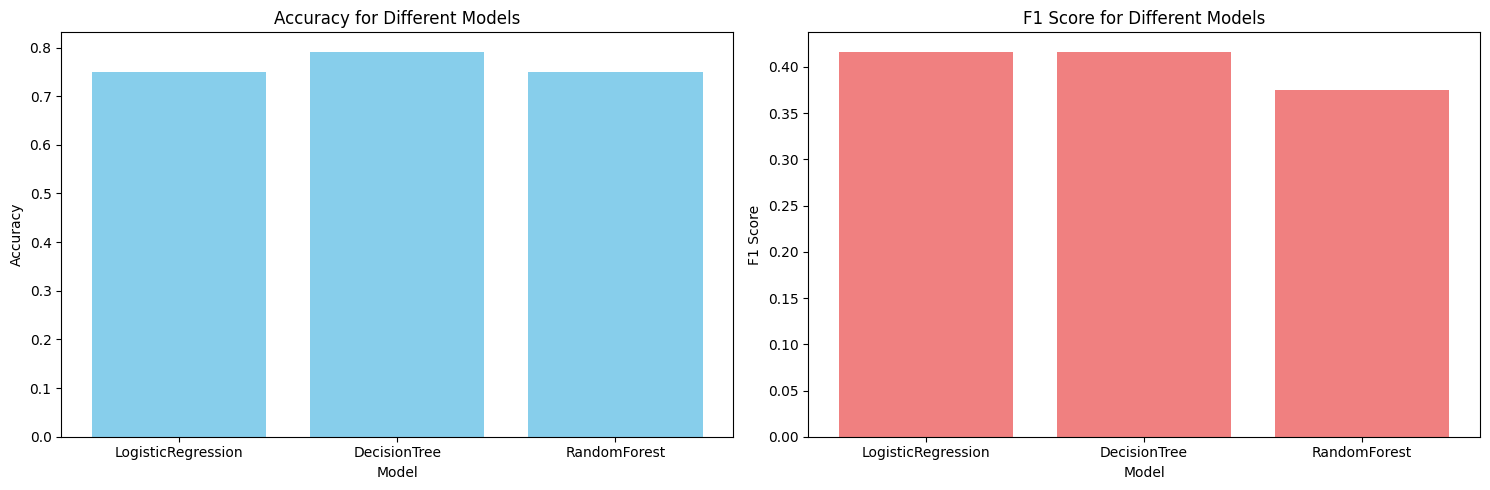

In [262]:
#sp3 activity, classification

import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Data preparation (Assuming dfNi and standardized_data are already defined)
X_select = []
y = []
indexes = []
for i in dfNi.index:
    indexes.append(i)
    X_select.append(list(standardized_data.iloc[i].values) + [
            dfNi['Structure_integrity_after_rxn'].iloc[i],
            dfNi['Ni_M_ratio'].iloc[i]
        ])
    if not pd.isna(dfNi['Selectivity_1'].iloc[i]):
        y.append((dfNi['Yield_1'].iloc[i] * (dfNi['Selectivity_1'].iloc[i]) +
                  dfNi['Yield_2'].iloc[i] * (dfNi['Selectivity_2'].iloc[i])) / 2)
    else:
        y.append(0)

X_select = pd.DataFrame(X_select, index=indexes,
                        columns=list(standardized_data.columns) + ['stability', 'Ni_M_ratio'])

# Binarize y based on the median value
y_median = np.median(y)
y = [1 if value > y_median else 0 for value in y]
y = pd.DataFrame(y, index=indexes, columns=['Class'])

# Define the number of folds for cross-validation
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
num_sample = len(np.unique(indexes))

# Store selected predictors
Selected_Factors = [[] for _ in range(num_sample)]
Accuracies = [[] for _ in range(num_sample)]
F1s = [[] for _ in range(num_sample)]

# Different models to try
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
}

trial_num = 0
for index in np.unique(indexes):
    print('Trial:', trial_num)
    # Build the LOO dataset by removing the current group
    X_train_val = X_select.drop([index])
    y_train_val = y.drop([index])
    X_test = X_select.loc[[index]]
    y_test = y.loc[[index]]

    for model_name, model in models.items():
        print(f"Model: {model_name}")

        # Recursive Feature Elimination with Cross-Validation for feature selection
        selector = RFECV(estimator=model, step=1, cv=kf, scoring='accuracy')
        selector = selector.fit(X_train_val, y_train_val.values.flatten())
        selected_features = X_train_val.columns[selector.support_]

        # Fit the model with selected features
        model.fit(X_train_val[selected_features], y_train_val.values.flatten())

        # Predictions for the test set
        y_pred_test = model.predict(X_test[selected_features])

        # Evaluation metrics for test set
        acc_test = accuracy_score(y_test, y_pred_test)
        f1_test = f1_score(y_test, y_pred_test)

        # Store metrics
        Accuracies[trial_num].append(acc_test)
        F1s[trial_num].append(f1_test)

        # Output performance
        print('Selected Features:', selected_features.tolist())
        print(f"Test Accuracy: {acc_test}")
        print(f"Test F1 Score: {f1_test}")

        Selected_Factors[trial_num].append(selected_features.tolist())

    trial_num += 1

# Visualization of Accuracy and F1 metrics
models_list = list(models.keys())
accuracy_values = np.mean(Accuracies, axis=0)
f1_values = np.mean(F1s, axis=0)

plt.figure(figsize=(15, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.bar(models_list, accuracy_values, color='skyblue')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy for Different Models')

# F1 Score plot
plt.subplot(1, 2, 2)
plt.bar(models_list, f1_values, color='lightcoral')
plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.title('F1 Score for Different Models')

plt.tight_layout()
plt.show()


In [263]:
import numpy as np
from collections import Counter

# Assuming df_reordered is the DataFrame containing factor correlations and 'factor_counter' is already defined
threshold = 0.8  # Set the correlation threshold

# Step 1: Group factors ensuring all pairs within the group have correlation above the threshold
factor_groups = []
visited = set()

for i in df_reordered.columns:
    if i in visited:
        continue
    # Start a candidate group with factor 'i'
    candidate_group = [i]
    for j in df_reordered.columns:
        if j in visited or i == j:
            continue
        # Check if 'j' can be added to the candidate group (i.e., it meets the correlation threshold with all existing members)
        if all(abs(df_reordered.loc[factor, j]) >= threshold for factor in candidate_group):
            candidate_group.append(j)
            visited.add(j)
    visited.add(i)
    # Add the candidate group to the list
    factor_groups.append(candidate_group)

# Step 2: Compute factor frequency based on unique groups to avoid double counting
factor_counter_groupwise = Counter()
factor_accuracy_groupwise = {}

# Count occurrences and accumulate accuracy values without double counting within each entry
for i in range(len(Selected_Factors)):
    for factors, acc in zip(Selected_Factors[i], Accuracies[i]):
        if isinstance(factors, list):  # Ensure factors is a list before iterating
            counted_groups = set()
            for group in factor_groups:
                # Check if any factors in the group are present in the current list of factors
                group_factors_in_entry = [factor for factor in factors if factor in group]
                if group_factors_in_entry:
                    # Only count the first occurrence in the group to avoid double counting within the entry
                    first_factor = group_factors_in_entry[0]
                    if tuple(group) not in counted_groups:
                        factor_counter_groupwise[first_factor] += 1
                        if first_factor in factor_accuracy_groupwise:
                            factor_accuracy_groupwise[first_factor].append(acc)
                        else:
                            factor_accuracy_groupwise[first_factor] = [acc]
                        counted_groups.add(tuple(group))

# Calculate average accuracy for each factor without double counting
factor_avg_accuracy_groupwise = {factor: np.mean(accs) for factor, accs in factor_accuracy_groupwise.items()}

# Step 3: Sum the factor frequencies within each group ensuring no double counting within each group
grouped_factor_counter = {}

for group in factor_groups:
    # Create a name for the group by joining factor names with their individual frequencies
    group_name = " & ".join(f"{factor}({factor_counter_groupwise[factor]})" for factor in group)
    grouped_count = sum(factor_counter_groupwise[factor] for factor in group)
    grouped_factor_counter[group_name] = grouped_count

# Step 4: Output the grouped factors with their summed frequencies, sorted by frequency in descending order
print("\nGrouped Factors with Summed Frequencies and Average Accuracy (Sorted by Frequency):")
for group, count in sorted(grouped_factor_counter.items(), key=lambda x: x[1], reverse=True):
    avg_accuracy = np.mean(
        [factor_avg_accuracy_groupwise[factor] for factor in group.split(" & ") if factor in factor_avg_accuracy_groupwise]
    )
    print(f"{group}: Frequency = {count}, Avg Accuracy = {avg_accuracy:.4f}")



Grouped Factors with Summed Frequencies and Average Accuracy (Sorted by Frequency):
Factor25(56) & Factor44(8): Frequency = 64, Avg Accuracy = nan
Factor15(60): Frequency = 60, Avg Accuracy = nan
Factor19(58): Frequency = 58, Avg Accuracy = nan
Factor14(57): Frequency = 57, Avg Accuracy = nan
Factor30(55): Frequency = 55, Avg Accuracy = nan
Factor27(55): Frequency = 55, Avg Accuracy = nan
Factor4(33) & Factor26(18): Frequency = 51, Avg Accuracy = nan
Factor1(30) & Factor34(21): Frequency = 51, Avg Accuracy = nan
Factor5(40) & Factor24(7): Frequency = 47, Avg Accuracy = nan
Factor6(46): Frequency = 46, Avg Accuracy = nan
Factor43(46): Frequency = 46, Avg Accuracy = nan
Factor22(45): Frequency = 45, Avg Accuracy = nan
Factor11(45): Frequency = 45, Avg Accuracy = nan
Factor7(44): Frequency = 44, Avg Accuracy = nan
Factor42(12) & Factor8(26): Frequency = 38, Avg Accuracy = nan
Factor29(21) & Factor33(13): Frequency = 34, Avg Accuracy = nan
Factor16(33): Frequency = 33, Avg Accuracy = nan


C:\Users\wavep\AppData\Roaming\Python\Python39\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\wavep\AppData\Roaming\Python\Python39\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, intercept]


Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 76 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
There were 3197 divergences after tuning. Increase `target_accept` or reparameterize.


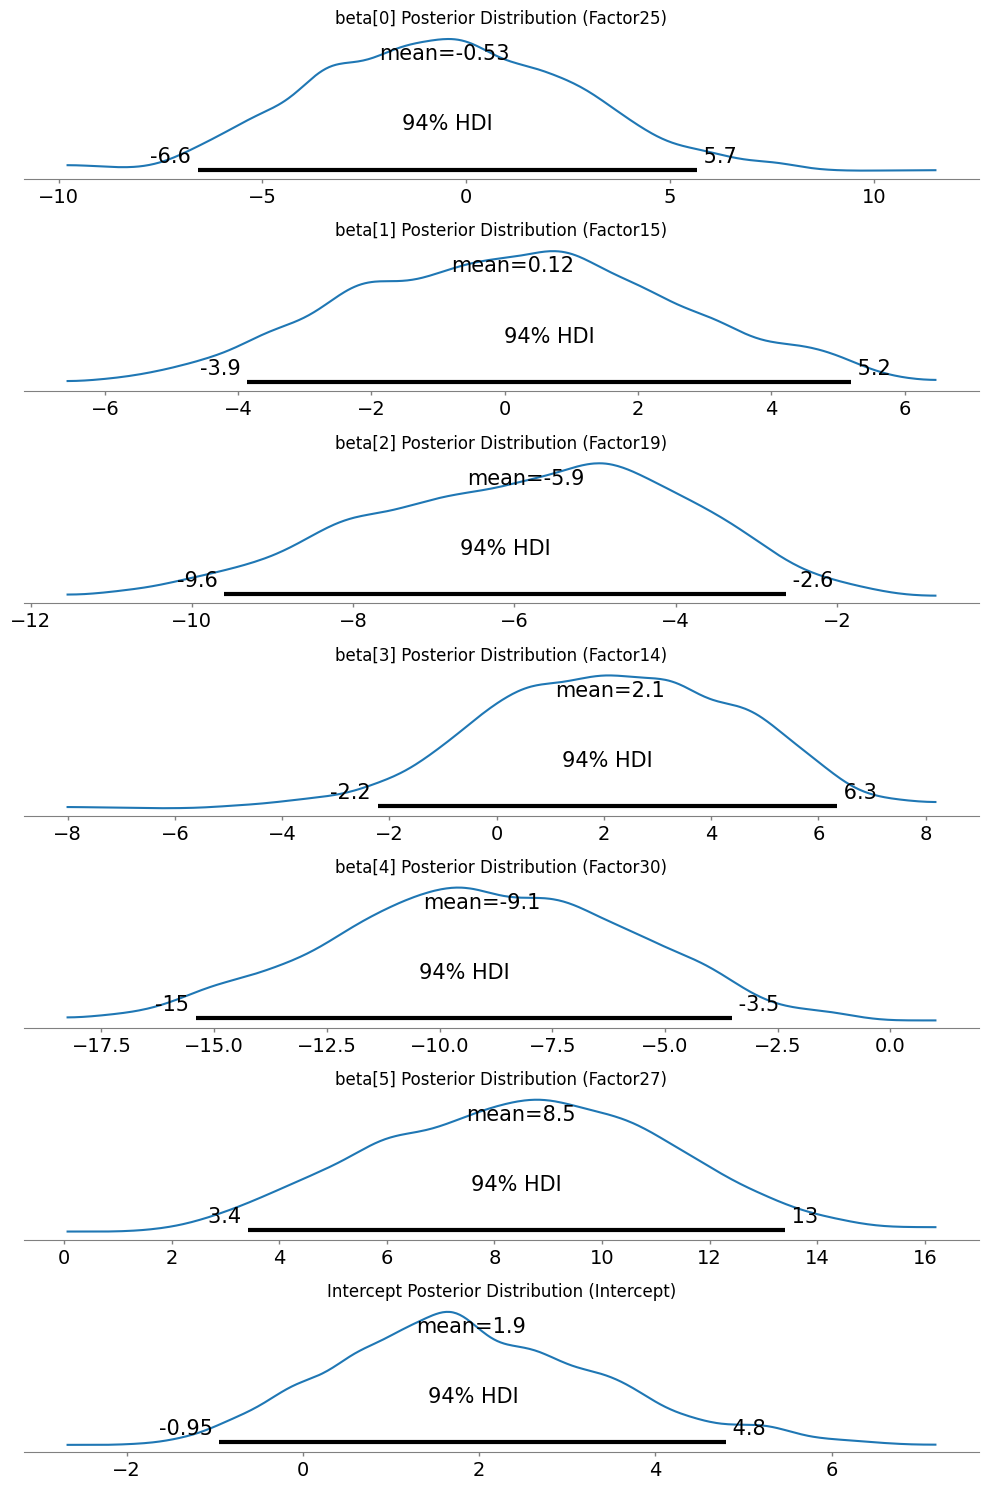

Sampling: [observed]


Accuracy: 0.9791666666666666
Classification Report:
              precision    recall  f1-score   support

       False       0.95      1.00      0.97        19
        True       1.00      0.97      0.98        29

    accuracy                           0.98        48
   macro avg       0.97      0.98      0.98        48
weighted avg       0.98      0.98      0.98        48



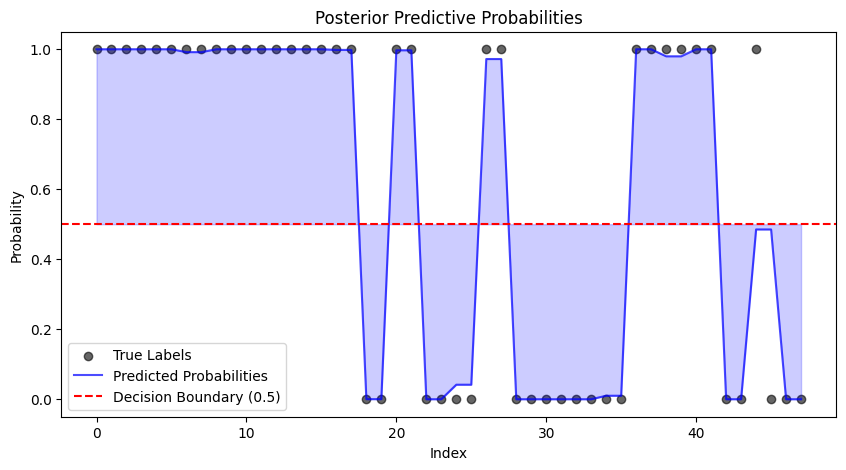

In [271]:
import pymc as pm
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
# 分类结果评估
from sklearn.metrics import accuracy_score, classification_report

# 数据准备
Selected_columns = ['Factor25', 'Factor15', 'Factor19','Factor14','Factor30','Factor27']

X_select = []
y = []
indexes = []
for i in dfNi.index:
    indexes.append(i)
    X_select.append(list(standardized_data.iloc[i].values) + [
            dfNi['Structure_integrity_after_rxn'].iloc[i],
            dfNi['Ni_M_ratio'].iloc[i]
        ])
    if not pd.isna(dfNi['Selectivity_1'].iloc[i]):
        y.append(dfNi['Yield_1'].iloc[i] * (dfNi['Selectivity_1'].iloc[i]) > y_median)
    else:
        y.append(False)
    indexes.append(i)
    X_select.append(list(standardized_data.iloc[i].values) + [
            dfNi['Structure_integrity_after_rxn'].iloc[i],
            dfNi['Ni_M_ratio'].iloc[i]
        ])
    if not pd.isna(dfNi['Selectivity_2'].iloc[i]):
        y.append(dfNi['Yield_2'].iloc[i] * (dfNi['Selectivity_2'].iloc[i]) > y_median)
    else:
        y.append(False)

X_select = pd.DataFrame(X_select, index=indexes, columns=list(standardized_data.columns) + ['stability', 'Ni_M_ratio'])
y = pd.DataFrame(y, index=indexes, columns=['Class'])

# 选择特征
X_select = X_select[Selected_columns]

# 贝叶斯分类建模
with pm.Model() as bayesian_logistic_model:
    # 定义先验分布
    beta = pm.Normal("beta", mu=0, sigma=10, shape=X_select.shape[1])
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    
    # 线性组合
    linear_combination = pm.math.dot(X_select.values, beta) + intercept
    
    # 激活函数 (sigmoid)
    p = pm.Deterministic("p", pm.math.sigmoid(linear_combination))
    
    # 观测分布
    observed = pm.Bernoulli("observed", p=p, observed=y['Class'].values)
    
    # 后验采样
    trace = pm.sample(1000, tune=2000, target_accept=0.95, random_seed=42)


# 提取变量名
variable_names = X_select.columns.tolist()

fig, axes = plt.subplots(len(trace.posterior["beta"].values.T) + 1, 1, figsize=(10, 15))  # 每个参数一个子图
for i, ax in enumerate(axes[:-1]):
    az.plot_posterior(trace.posterior["beta"][:, :, i], ax=ax)
    # 在标题中添加对应的变量名
    ax.set_title(f"beta[{i}] Posterior Distribution ({variable_names[i]})")

# 绘制 intercept
az.plot_posterior(trace.posterior["intercept"], ax=axes[-1])
axes[-1].set_title("Intercept Posterior Distribution (Intercept)")

plt.tight_layout()
plt.show()


# 从后验样本中提取参数并计算预测概率
with bayesian_logistic_model:
    posterior_predictive = pm.sample_posterior_predictive(trace)
    
# 提取参数
beta_samples = trace.posterior["beta"].mean(axis=(0, 1)).values
intercept_sample = trace.posterior["intercept"].mean(axis=(0, 1)).values

# 计算预测概率
linear_combination = np.dot(X_select.values, beta_samples) + intercept_sample
pred_mean = 1 / (1 + np.exp(-linear_combination))  # Sigmoid 函数
y_pred = (pred_mean > 0.5).astype(int)

# 分类结果评估
accuracy = accuracy_score(y['Class'].values, y_pred)
print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(classification_report(y['Class'].values, y_pred))



# 绘图
plt.figure(figsize=(10, 5))
plt.scatter(np.arange(len(y)), y['Class'], label="True Labels", alpha=0.6, color="black")
plt.plot(np.arange(len(y)), pred_mean, label="Predicted Probabilities", alpha=0.7, color="blue")
plt.axhline(0.5, linestyle="--", color="red", label="Decision Boundary (0.5)")
plt.fill_between(np.arange(len(y)), 0.5, pred_mean, alpha=0.2, color="blue")
plt.legend()
plt.xlabel("Index")
plt.ylabel("Probability")
plt.title("Posterior Predictive Probabilities")
plt.show()


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, intercept]


Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 56 seconds.
There were 1397 divergences after tuning. Increase `target_accept` or reparameterize.


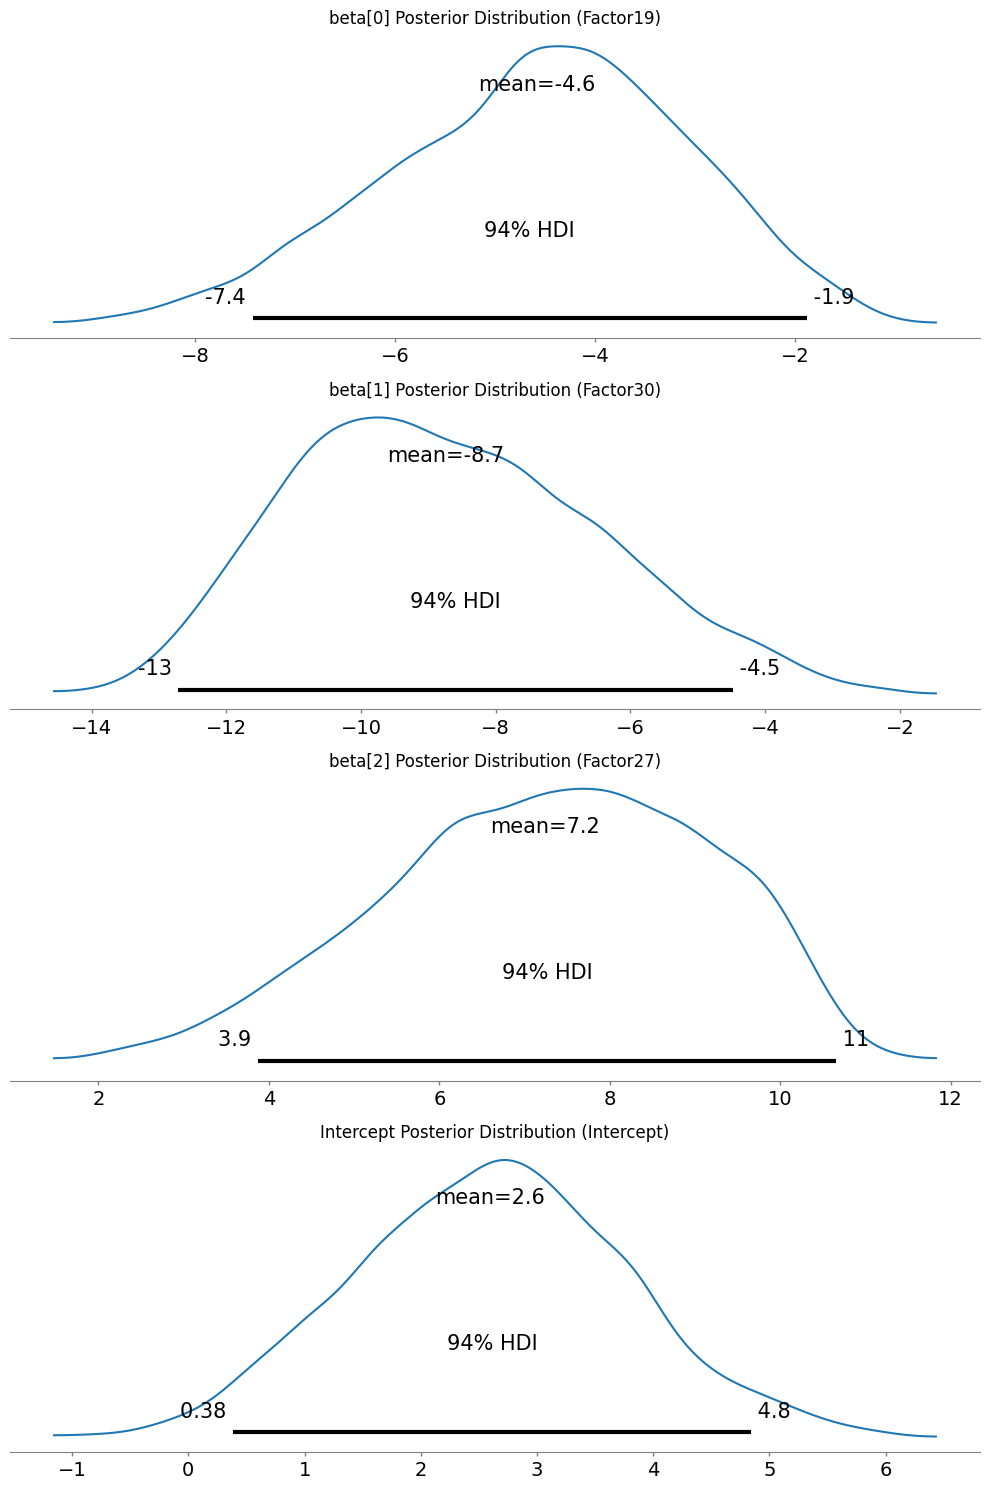

Sampling: [observed]


Accuracy: 0.9791666666666666
Classification Report:
              precision    recall  f1-score   support

       False       0.95      1.00      0.97        19
        True       1.00      0.97      0.98        29

    accuracy                           0.98        48
   macro avg       0.97      0.98      0.98        48
weighted avg       0.98      0.98      0.98        48



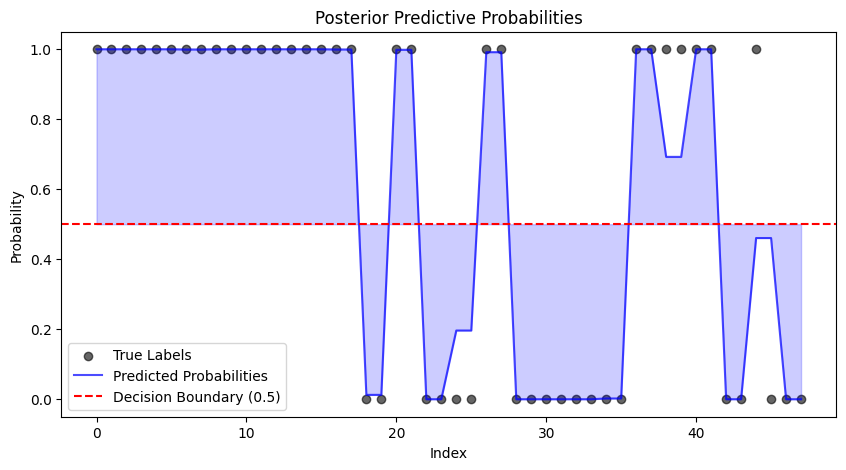

<Figure size 800x600 with 0 Axes>

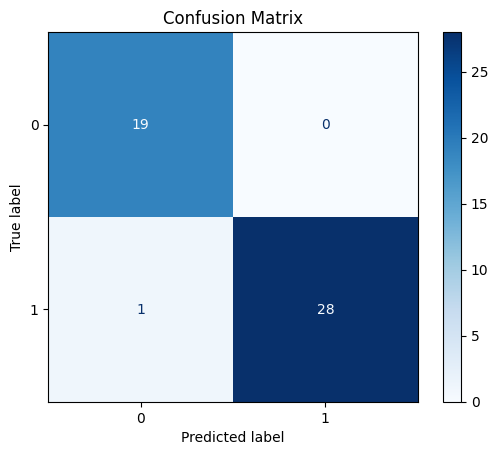

In [273]:
import pymc as pm
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
# 分类结果评估
from sklearn.metrics import accuracy_score, classification_report

# 数据准备
Selected_columns = ['Factor19', 'Factor30', 'Factor27']

X_select = []
y = []
indexes = []
for i in dfNi.index:
    indexes.append(i)
    X_select.append(list(standardized_data.iloc[i].values) + [
            dfNi['Structure_integrity_after_rxn'].iloc[i],
            dfNi['Ni_M_ratio'].iloc[i]
        ])
    if not pd.isna(dfNi['Selectivity_1'].iloc[i]):
        y.append(dfNi['Yield_1'].iloc[i] * (dfNi['Selectivity_1'].iloc[i]) > y_median)
    else:
        y.append(False)
    indexes.append(i)
    X_select.append(list(standardized_data.iloc[i].values) + [
            dfNi['Structure_integrity_after_rxn'].iloc[i],
            dfNi['Ni_M_ratio'].iloc[i]
        ])
    if not pd.isna(dfNi['Selectivity_2'].iloc[i]):
        y.append(dfNi['Yield_2'].iloc[i] * (dfNi['Selectivity_2'].iloc[i]) > y_median)
    else:
        y.append(False)

X_select = pd.DataFrame(X_select, index=indexes, columns=list(standardized_data.columns) + ['stability', 'Ni_M_ratio'])
y = pd.DataFrame(y, index=indexes, columns=['Class'])

# 选择特征
X_select = X_select[Selected_columns]

# 贝叶斯分类建模
with pm.Model() as bayesian_logistic_model:
    # 定义先验分布
    beta = pm.Normal("beta", mu=0, sigma=10, shape=X_select.shape[1])
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    
    # 线性组合
    linear_combination = pm.math.dot(X_select.values, beta) + intercept
    
    # 激活函数 (sigmoid)
    p = pm.Deterministic("p", pm.math.sigmoid(linear_combination))
    
    # 观测分布
    observed = pm.Bernoulli("observed", p=p, observed=y['Class'].values)
    
    # 后验采样
    trace = pm.sample(1000, tune=2000, target_accept=0.95, random_seed=42)


# 提取变量名
variable_names = X_select.columns.tolist()

fig, axes = plt.subplots(len(trace.posterior["beta"].values.T) + 1, 1, figsize=(10, 15))  # 每个参数一个子图
for i, ax in enumerate(axes[:-1]):
    az.plot_posterior(trace.posterior["beta"][:, :, i], ax=ax)
    # 在标题中添加对应的变量名
    ax.set_title(f"beta[{i}] Posterior Distribution ({variable_names[i]})")

# 绘制 intercept
az.plot_posterior(trace.posterior["intercept"], ax=axes[-1])
axes[-1].set_title("Intercept Posterior Distribution (Intercept)")

plt.tight_layout()
plt.show()


# 从后验样本中提取参数并计算预测概率
with bayesian_logistic_model:
    posterior_predictive = pm.sample_posterior_predictive(trace)
    
# 提取参数
beta_samples = trace.posterior["beta"].mean(axis=(0, 1)).values
intercept_sample = trace.posterior["intercept"].mean(axis=(0, 1)).values

# 计算预测概率
linear_combination = np.dot(X_select.values, beta_samples) + intercept_sample
pred_mean = 1 / (1 + np.exp(-linear_combination))  # Sigmoid 函数
y_pred = (pred_mean > 0.5).astype(int)

# 分类结果评估
accuracy = accuracy_score(y['Class'].values, y_pred)
print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(classification_report(y['Class'].values, y_pred))



# 绘图
plt.figure(figsize=(10, 5))
plt.scatter(np.arange(len(y)), y['Class'], label="True Labels", alpha=0.6, color="black")
plt.plot(np.arange(len(y)), pred_mean, label="Predicted Probabilities", alpha=0.7, color="blue")
plt.axhline(0.5, linestyle="--", color="red", label="Decision Boundary (0.5)")
plt.fill_between(np.arange(len(y)), 0.5, pred_mean, alpha=0.2, color="blue")
plt.legend()
plt.xlabel("Index")
plt.ylabel("Probability")
plt.title("Posterior Predictive Probabilities")
plt.show()

# 计算混淆矩阵
cm = confusion_matrix(y['Class'].values, y_pred)

# 绘制混淆矩阵
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

Trial: 0
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 1
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 2
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 3
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 4
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 5
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 6
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 7
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 8
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 9
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 10
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 11
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 12
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 13
Model: Logis

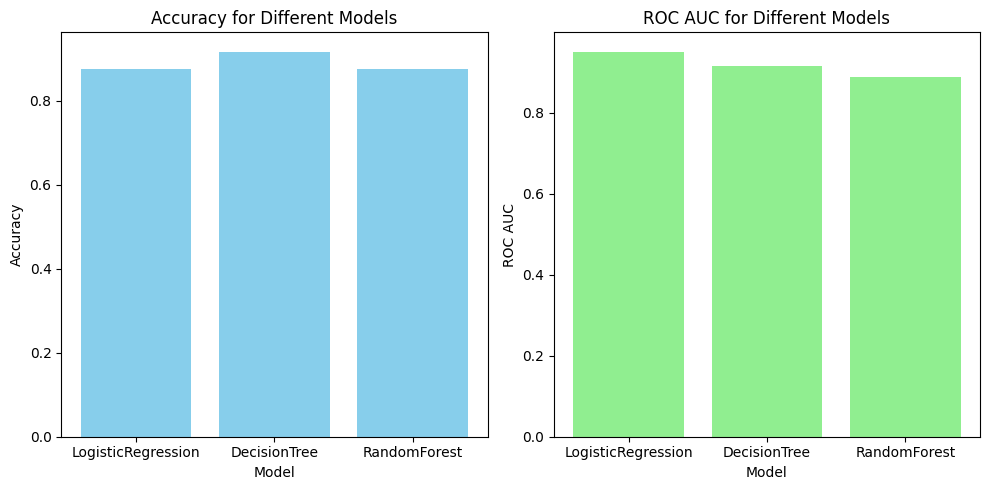

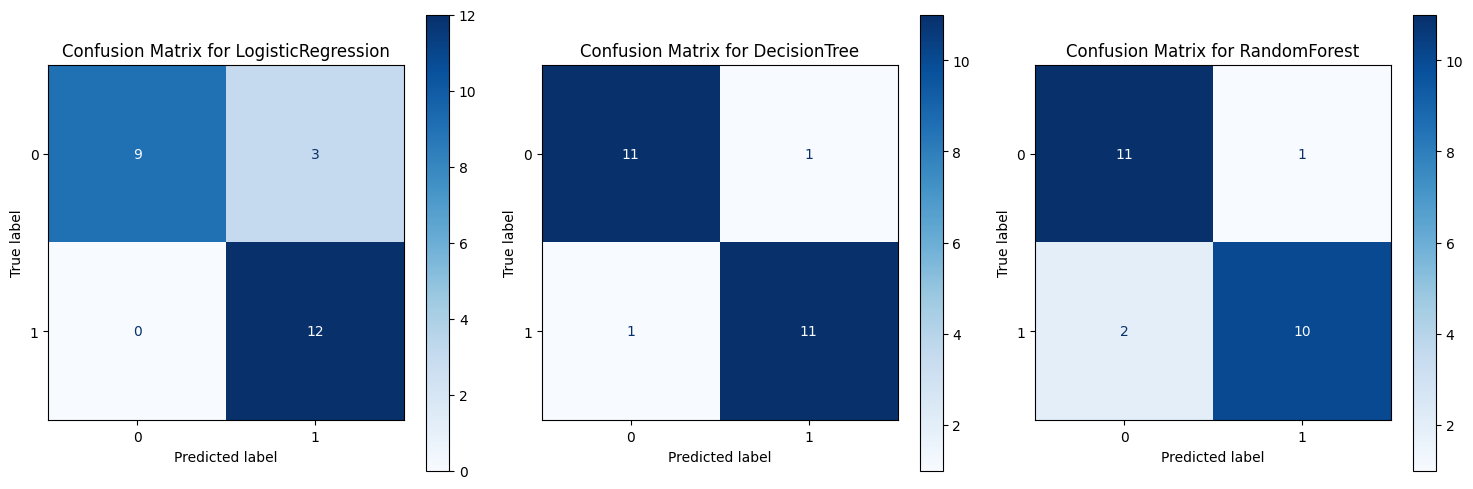

In [ ]:
#LOO classification

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

Selected_columns = ['Factor19', 'Factor30','Factor27']
X_select = []
y = []
indexes = []
for i in dfNi.index:
    indexes.append(i)
    X_select.append(list(standardized_data.iloc[i].values) + [
            dfNi['Structure_integrity_after_rxn'].iloc[i],
            dfNi['Ni_M_ratio'].iloc[i]
        ])
    if not pd.isna(dfNi['Selectivity_1'].iloc[i]):
        y.append((dfNi['Yield_1'].iloc[i] * (dfNi['Selectivity_1'].iloc[i]) +
                  dfNi['Yield_2'].iloc[i] * (dfNi['Selectivity_2'].iloc[i])) / 2)
    else:
        y.append(0)

X_select = pd.DataFrame(X_select, index=indexes,
                        columns=list(standardized_data.columns) + ['stability', 'Ni_M_ratio'])

# Binarize y based on the median value
y_median = np.median(y)
y = [1 if value > y_median else 0 for value in y]
y = pd.DataFrame(y, index=indexes, columns=['Class'])

# 留一法测试
num_sample = len(np.unique(indexes))

# 初始化存储变量
test_and_predicted = [[] for _ in range(num_sample)]

# 不同的分类模型
models = {
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
}

trial_num = 0
for index in np.unique(indexes):
    print('Trial:', trial_num)
    # 构造 LOO 数据集
    X_train_val = X_select.drop([index])
    y_train_val = y.drop([index])
    X_test = X_select.loc[[index]]
    y_test = y.loc[[index]]

    for model_name, model in models.items():
        print(f"Model: {model_name}")
        
        # 训练模型
        model.fit(X_train_val, y_train_val.values.flatten())
        
        # 预测测试集
        y_pred_test = model.predict(X_test)
        y_pred_prob = model.predict_proba(X_test)[:, 1]  # 获取概率

        # 存储真实值和预测值
        test_and_predicted[trial_num].append([y_test.values[0][0], y_pred_test[0], y_pred_prob[0]])

    trial_num += 1



# 分类结果分析
models_list = list(models.keys())
accuracy_values = []
roc_auc_values = []
confusion_matrices = []  # 存储混淆矩阵
test_and_predicted = np.array(test_and_predicted)

# 计算分类指标
for i in range(len(models_list)):
    true_values = test_and_predicted[:, i, 0].astype(int)
    predicted_values = test_and_predicted[:, i, 1].astype(int)
    predicted_probs = test_and_predicted[:, i, 2]

    # 计算 Accuracy 和 ROC_AUC
    accuracy = accuracy_score(true_values, predicted_values)
    roc_auc = roc_auc_score(true_values, predicted_probs)

    accuracy_values.append(accuracy)
    roc_auc_values.append(roc_auc)

    # 计算混淆矩阵
    cm = confusion_matrix(true_values, predicted_values)
    confusion_matrices.append(cm)

# 打印平均指标
for model_name, accuracy, roc_auc in zip(models_list, accuracy_values, roc_auc_values):
    print(f"{model_name}:")
    print(f"  Mean Accuracy: {accuracy:.4f}")
    print(f"  Mean ROC_AUC: {roc_auc:.4f}")

# 可视化分类指标
plt.figure(figsize=(10, 5))

# 绘制 Accuracy
plt.subplot(1, 2, 1)
plt.bar(models_list, accuracy_values, color='skyblue')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy for Different Models')

# 绘制 ROC_AUC
plt.subplot(1, 2, 2)
plt.bar(models_list, roc_auc_values, color='lightgreen')
plt.xlabel('Model')
plt.ylabel('ROC AUC')
plt.title('ROC AUC for Different Models')

plt.tight_layout()
plt.show()

# 可视化混淆矩阵
plt.figure(figsize=(15, 5))
for i, cm in enumerate(confusion_matrices):
    plt.subplot(1, len(models_list), i + 1)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=plt.gca(), cmap="Blues", values_format="d")
    plt.title(f'Confusion Matrix for {models_list[i]}')

plt.tight_layout()
plt.show()



Trial: 0
Model: LogisticRegression
Selected Features: ['Factor30']
Test Accuracy: 0.0
Test F1 Score: 0.0
Model: DecisionTree
Selected Features: ['Factor3', 'Factor4', 'Factor5', 'Factor6', 'Factor7', 'Factor8', 'Factor9', 'Factor10', 'Factor11', 'Factor12', 'Factor13', 'Factor14', 'Factor15', 'Factor16', 'Factor17', 'Factor18', 'Factor19', 'Factor20', 'Factor21', 'Factor22', 'Factor23', 'Factor24', 'Factor25', 'Factor26', 'Factor27', 'Factor28', 'Factor29', 'Factor30', 'Factor31', 'Factor32', 'Factor33', 'Factor34', 'Factor35', 'Factor36', 'Factor37', 'Factor38', 'Factor39', 'Factor40', 'Factor41', 'Factor42', 'Factor43', 'Factor44', 'Factor45', 'stability', 'Ni_M_ratio']
Test Accuracy: 0.0
Test F1 Score: 0.0
Model: RandomForest
Selected Features: ['Factor5', 'Factor21', 'Factor30']
Test Accuracy: 0.0
Test F1 Score: 0.0
Trial: 1
Model: LogisticRegression
Selected Features: ['Factor1', 'Factor10', 'Factor15', 'Factor22', 'Factor27', 'Factor30', 'Factor40']
Test Accuracy: 0.0
Test F1 Sco

d:\Anaconda3\envs\rdkit\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Selected Features: ['Factor5']
Test Accuracy: 1.0
Test F1 Score: 0.0
Model: RandomForest


d:\Anaconda3\envs\rdkit\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Selected Features: ['Factor5', 'Factor15']
Test Accuracy: 1.0
Test F1 Score: 0.0
Trial: 12
Model: LogisticRegression
Selected Features: ['Factor15']
Test Accuracy: 0.0
Test F1 Score: 0.0
Model: DecisionTree


...

Selected Features: ['Factor1', 'Factor5', 'Factor9', 'Factor10', 'Factor15', 'Factor16', 'Factor18', 'Factor22', 'Factor27', 'Factor30', 'Factor32', 'Factor34', 'Factor35', 'Factor39', 'Factor40']
Test Accuracy: 1.0
Test F1 Score: 0.0
Model: DecisionTree


d:\Anaconda3\envs\rdkit\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Selected Features: ['Factor5', 'Factor6', 'Factor7', 'Factor8', 'Factor9', 'Factor10', 'Factor11', 'Factor12', 'Factor13', 'Factor14', 'Factor15', 'Factor16', 'Factor17', 'Factor18', 'Factor19', 'Factor20', 'Factor21', 'Factor22', 'Factor23', 'Factor24', 'Factor27', 'Factor28', 'Factor29', 'Factor30', 'Factor31', 'Factor32', 'Factor33', 'Factor34', 'Factor35', 'Factor36', 'Factor37', 'Factor38', 'Factor39', 'Factor40', 'Factor41', 'Factor42', 'Factor43', 'Factor44', 'Factor45', 'stability', 'Ni_M_ratio']
Test Accuracy: 1.0
Test F1 Score: 0.0
Model: RandomForest


d:\Anaconda3\envs\rdkit\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Selected Features: ['Factor5', 'Factor27']
Test Accuracy: 1.0
Test F1 Score: 0.0


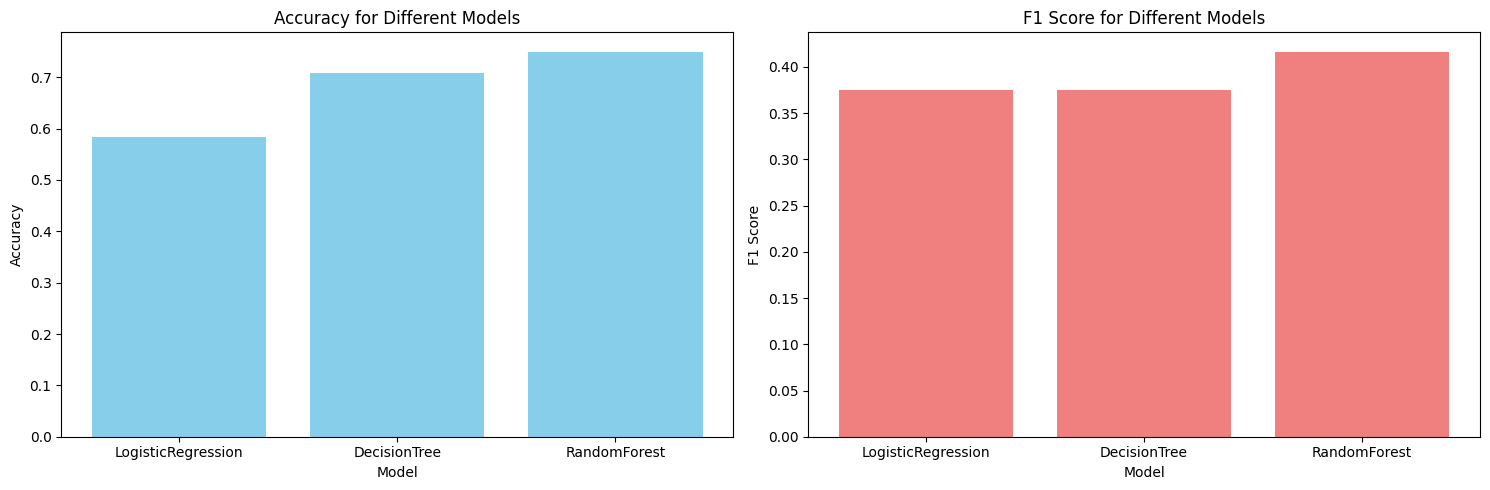

In [277]:
#sp2 activity, classification

import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Data preparation (Assuming dfNi and standardized_data are already defined)
X_select = []
y = []
indexes = []
for i in dfNi.index:
    indexes.append(i)
    X_select.append(list(standardized_data.iloc[i].values) + [
            dfNi['Structure_integrity_after_rxn'].iloc[i],
            dfNi['Ni_M_ratio'].iloc[i]
        ])
    if not pd.isna(dfNi['Selectivity_1'].iloc[i]):
        y.append((dfNi['Yield_1'].iloc[i] * (1 - dfNi['Selectivity_1'].iloc[i]) +
                  dfNi['Yield_2'].iloc[i] * (1 - dfNi['Selectivity_2'].iloc[i])) / 2)
    else:
        y.append(0)

X_select = pd.DataFrame(X_select, index=indexes,
                        columns=list(standardized_data.columns) + ['stability', 'Ni_M_ratio'])

# Binarize y based on the median value
y_median = np.median(y)
y = [1 if value > y_median else 0 for value in y]
y = pd.DataFrame(y, index=indexes, columns=['Class'])

# Define the number of folds for cross-validation
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
num_sample = len(np.unique(indexes))

# Store selected predictors
Selected_Factors = [[] for _ in range(num_sample)]
Accuracies = [[] for _ in range(num_sample)]
F1s = [[] for _ in range(num_sample)]

# Different models to try
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
}

trial_num = 0
for index in np.unique(indexes):
    print('Trial:', trial_num)
    # Build the LOO dataset by removing the current group
    X_train_val = X_select.drop([index])
    y_train_val = y.drop([index])
    X_test = X_select.loc[[index]]
    y_test = y.loc[[index]]

    for model_name, model in models.items():
        print(f"Model: {model_name}")

        # Recursive Feature Elimination with Cross-Validation for feature selection
        selector = RFECV(estimator=model, step=1, cv=kf, scoring='accuracy')
        selector = selector.fit(X_train_val, y_train_val.values.flatten())
        selected_features = X_train_val.columns[selector.support_]

        # Fit the model with selected features
        model.fit(X_train_val[selected_features], y_train_val.values.flatten())

        # Predictions for the test set
        y_pred_test = model.predict(X_test[selected_features])

        # Evaluation metrics for test set
        acc_test = accuracy_score(y_test, y_pred_test)
        f1_test = f1_score(y_test, y_pred_test)

        # Store metrics
        Accuracies[trial_num].append(acc_test)
        F1s[trial_num].append(f1_test)

        # Output performance
        print('Selected Features:', selected_features.tolist())
        print(f"Test Accuracy: {acc_test}")
        print(f"Test F1 Score: {f1_test}")

        Selected_Factors[trial_num].append(selected_features.tolist())

    trial_num += 1

# Visualization of Accuracy and F1 metrics
models_list = list(models.keys())
accuracy_values = np.mean(Accuracies, axis=0)
f1_values = np.mean(F1s, axis=0)

plt.figure(figsize=(15, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.bar(models_list, accuracy_values, color='skyblue')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy for Different Models')

# F1 Score plot
plt.subplot(1, 2, 2)
plt.bar(models_list, f1_values, color='lightcoral')
plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.title('F1 Score for Different Models')

plt.tight_layout()
plt.show()


In [278]:
import numpy as np
from collections import Counter

# Assuming df_reordered is the DataFrame containing factor correlations and 'factor_counter' is already defined
threshold = 0.8  # Set the correlation threshold

# Step 1: Group factors ensuring all pairs within the group have correlation above the threshold
factor_groups = []
visited = set()

for i in df_reordered.columns:
    if i in visited:
        continue
    # Start a candidate group with factor 'i'
    candidate_group = [i]
    for j in df_reordered.columns:
        if j in visited or i == j:
            continue
        # Check if 'j' can be added to the candidate group (i.e., it meets the correlation threshold with all existing members)
        if all(abs(df_reordered.loc[factor, j]) >= threshold for factor in candidate_group):
            candidate_group.append(j)
            visited.add(j)
    visited.add(i)
    # Add the candidate group to the list
    factor_groups.append(candidate_group)

# Step 2: Compute factor frequency based on unique groups to avoid double counting
factor_counter_groupwise = Counter()
factor_accuracy_groupwise = {}

# Count occurrences and accumulate accuracy values without double counting within each entry
for i in range(len(Selected_Factors)):
    for factors, acc in zip(Selected_Factors[i], Accuracies[i]):
        if isinstance(factors, list):  # Ensure factors is a list before iterating
            counted_groups = set()
            for group in factor_groups:
                # Check if any factors in the group are present in the current list of factors
                group_factors_in_entry = [factor for factor in factors if factor in group]
                if group_factors_in_entry:
                    # Only count the first occurrence in the group to avoid double counting within the entry
                    first_factor = group_factors_in_entry[0]
                    if tuple(group) not in counted_groups:
                        factor_counter_groupwise[first_factor] += 1
                        if first_factor in factor_accuracy_groupwise:
                            factor_accuracy_groupwise[first_factor].append(acc)
                        else:
                            factor_accuracy_groupwise[first_factor] = [acc]
                        counted_groups.add(tuple(group))

# Calculate average accuracy for each factor without double counting
factor_avg_accuracy_groupwise = {factor: np.mean(accs) for factor, accs in factor_accuracy_groupwise.items()}

# Step 3: Sum the factor frequencies within each group ensuring no double counting within each group
grouped_factor_counter = {}

for group in factor_groups:
    # Create a name for the group by joining factor names with their individual frequencies
    group_name = " & ".join(f"{factor}({factor_counter_groupwise[factor]})" for factor in group)
    grouped_count = sum(factor_counter_groupwise[factor] for factor in group)
    grouped_factor_counter[group_name] = grouped_count

# Step 4: Output the grouped factors with their summed frequencies, sorted by frequency in descending order
print("\nGrouped Factors with Summed Frequencies and Average Accuracy (Sorted by Frequency):")
for group, count in sorted(grouped_factor_counter.items(), key=lambda x: x[1], reverse=True):
    avg_accuracy = np.mean(
        [factor_avg_accuracy_groupwise[factor] for factor in group.split(" & ") if factor in factor_avg_accuracy_groupwise]
    )
    print(f"{group}: Frequency = {count}, Avg Accuracy = {avg_accuracy:.4f}")



Grouped Factors with Summed Frequencies and Average Accuracy (Sorted by Frequency):
Factor5(49) & Factor24(0): Frequency = 49, Avg Accuracy = nan
Factor30(38): Frequency = 38, Avg Accuracy = nan
Factor15(33): Frequency = 33, Avg Accuracy = nan
Factor10(21): Frequency = 21, Avg Accuracy = nan
Factor27(20): Frequency = 20, Avg Accuracy = nan
Factor16(20): Frequency = 20, Avg Accuracy = nan
Factor40(18): Frequency = 18, Avg Accuracy = nan
Factor1(7) & Factor34(11): Frequency = 18, Avg Accuracy = nan
Factor9(17): Frequency = 17, Avg Accuracy = nan
Factor6(16): Frequency = 16, Avg Accuracy = nan
Factor18(15) & Factor38(1): Frequency = 16, Avg Accuracy = nan
Factor22(15): Frequency = 15, Avg Accuracy = nan
Factor43(15): Frequency = 15, Avg Accuracy = nan
Factor21(1) & Factor17(14): Frequency = 15, Avg Accuracy = nan
Factor39(15): Frequency = 15, Avg Accuracy = nan
Factor42(0) & Factor8(14): Frequency = 14, Avg Accuracy = nan
Factor35(2) & Factor12(12) & Factor28(0): Frequency = 14, Avg Accu

C:\Users\wavep\AppData\Roaming\Python\Python39\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\wavep\AppData\Roaming\Python\Python39\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, intercept]


Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 47 seconds.


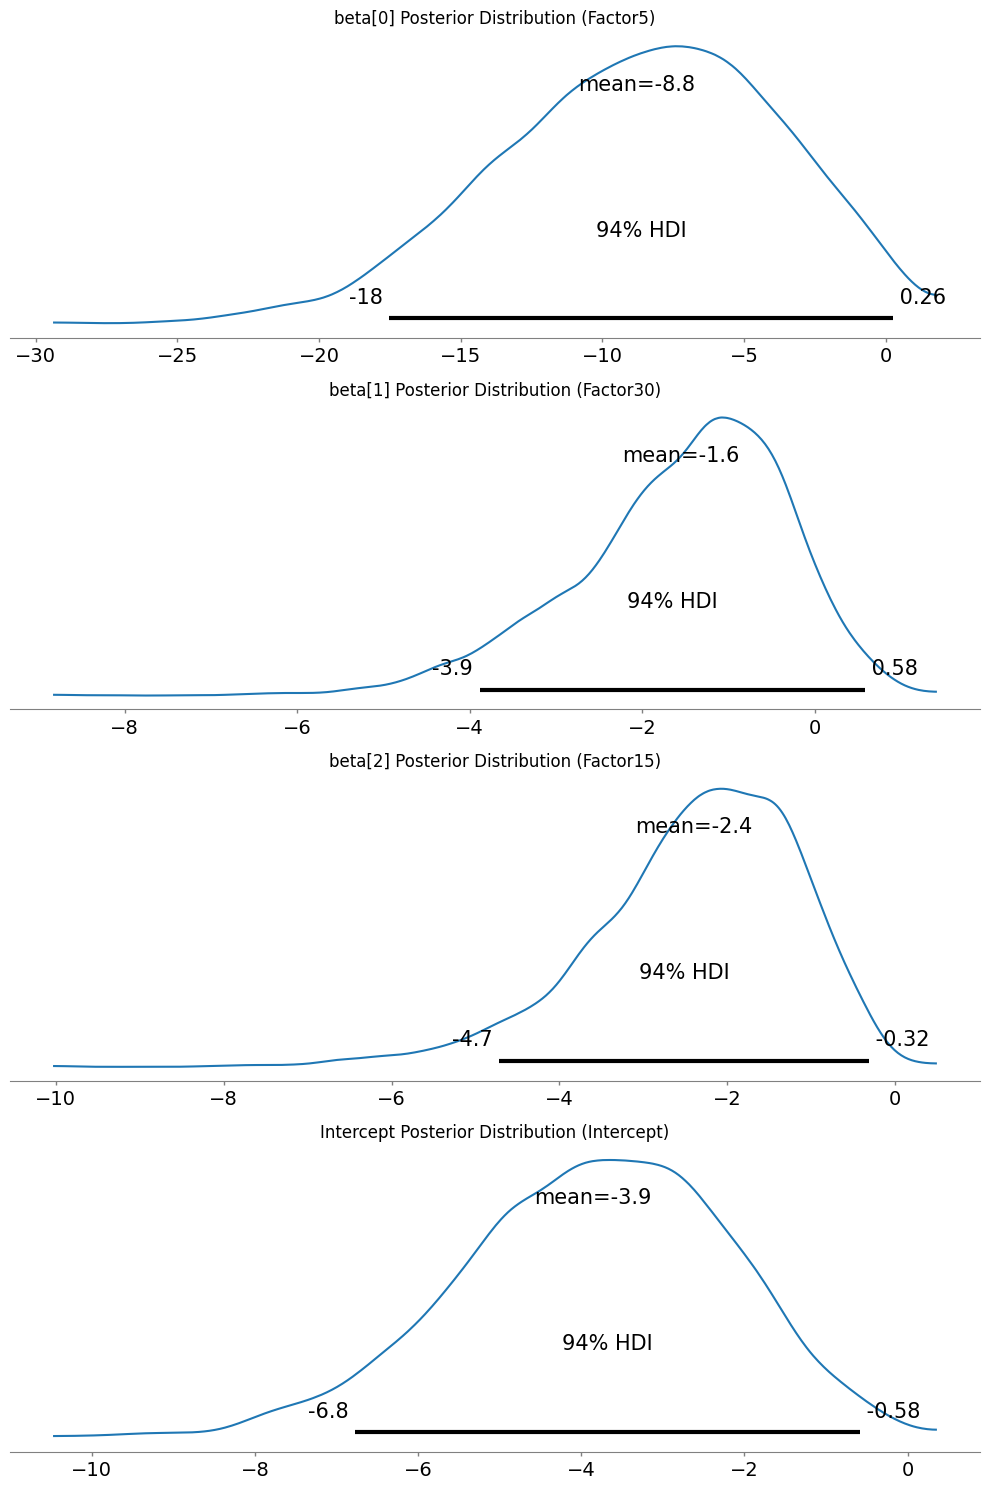

Sampling: [observed]


Accuracy: 0.875
Classification Report:
              precision    recall  f1-score   support

       False       1.00      0.75      0.86        24
        True       0.80      1.00      0.89        24

    accuracy                           0.88        48
   macro avg       0.90      0.88      0.87        48
weighted avg       0.90      0.88      0.87        48



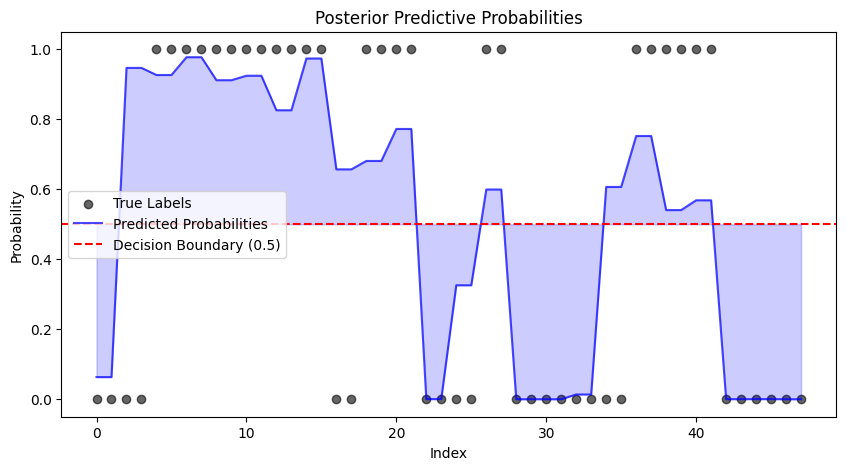

In [279]:
import pymc as pm
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
# 分类结果评估
from sklearn.metrics import accuracy_score, classification_report

# 数据准备
Selected_columns = ['Factor5', 'Factor30', 'Factor15']

X_select = []
y = []
indexes = []
for i in dfNi.index:
    indexes.append(i)
    X_select.append(list(standardized_data.iloc[i].values) + [
            dfNi['Structure_integrity_after_rxn'].iloc[i],
            dfNi['Ni_M_ratio'].iloc[i]
        ])
    if not pd.isna(dfNi['Selectivity_1'].iloc[i]):
        y.append(dfNi['Yield_1'].iloc[i] * (1 - dfNi['Selectivity_1'].iloc[i]) > y_median)
    else:
        y.append(False)
    indexes.append(i)
    X_select.append(list(standardized_data.iloc[i].values) + [
            dfNi['Structure_integrity_after_rxn'].iloc[i],
            dfNi['Ni_M_ratio'].iloc[i]
        ])
    if not pd.isna(dfNi['Selectivity_2'].iloc[i]):
        y.append(dfNi['Yield_2'].iloc[i] * (1 - dfNi['Selectivity_2'].iloc[i]) > y_median)
    else:
        y.append(False)

X_select = pd.DataFrame(X_select, index=indexes, columns=list(standardized_data.columns) + ['stability', 'Ni_M_ratio'])
y = pd.DataFrame(y, index=indexes, columns=['Class'])

# 选择特征
X_select = X_select[Selected_columns]

# 贝叶斯分类建模
with pm.Model() as bayesian_logistic_model:
    # 定义先验分布
    beta = pm.Normal("beta", mu=0, sigma=10, shape=X_select.shape[1])
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    
    # 线性组合
    linear_combination = pm.math.dot(X_select.values, beta) + intercept
    
    # 激活函数 (sigmoid)
    p = pm.Deterministic("p", pm.math.sigmoid(linear_combination))
    
    # 观测分布
    observed = pm.Bernoulli("observed", p=p, observed=y['Class'].values)
    
    # 后验采样
    trace = pm.sample(1000, tune=2000, target_accept=0.95, random_seed=42)


# 提取变量名
variable_names = X_select.columns.tolist()

fig, axes = plt.subplots(len(trace.posterior["beta"].values.T) + 1, 1, figsize=(10, 15))  # 每个参数一个子图
for i, ax in enumerate(axes[:-1]):
    az.plot_posterior(trace.posterior["beta"][:, :, i], ax=ax)
    # 在标题中添加对应的变量名
    ax.set_title(f"beta[{i}] Posterior Distribution ({variable_names[i]})")

# 绘制 intercept
az.plot_posterior(trace.posterior["intercept"], ax=axes[-1])
axes[-1].set_title("Intercept Posterior Distribution (Intercept)")

plt.tight_layout()
plt.show()


# 从后验样本中提取参数并计算预测概率
with bayesian_logistic_model:
    posterior_predictive = pm.sample_posterior_predictive(trace)
    
# 提取参数
beta_samples = trace.posterior["beta"].mean(axis=(0, 1)).values
intercept_sample = trace.posterior["intercept"].mean(axis=(0, 1)).values

# 计算预测概率
linear_combination = np.dot(X_select.values, beta_samples) + intercept_sample
pred_mean = 1 / (1 + np.exp(-linear_combination))  # Sigmoid 函数
y_pred = (pred_mean > 0.5).astype(int)

# 分类结果评估
accuracy = accuracy_score(y['Class'].values, y_pred)
print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(classification_report(y['Class'].values, y_pred))



# 绘图
plt.figure(figsize=(10, 5))
plt.scatter(np.arange(len(y)), y['Class'], label="True Labels", alpha=0.6, color="black")
plt.plot(np.arange(len(y)), pred_mean, label="Predicted Probabilities", alpha=0.7, color="blue")
plt.axhline(0.5, linestyle="--", color="red", label="Decision Boundary (0.5)")
plt.fill_between(np.arange(len(y)), 0.5, pred_mean, alpha=0.2, color="blue")
plt.legend()
plt.xlabel("Index")
plt.ylabel("Probability")
plt.title("Posterior Predictive Probabilities")
plt.show()


Trial: 0
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 1
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 2
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 3
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 4
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 5
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 6
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 7
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 8
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 9
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 10
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 11
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 12
Model: LogisticRegression
Model: DecisionTree
Model: RandomForest
Trial: 13
Model: Logis

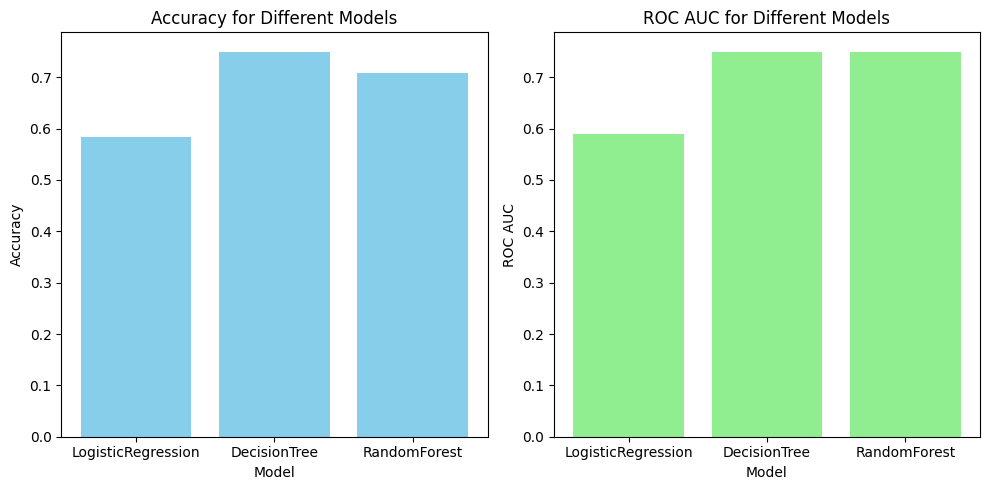

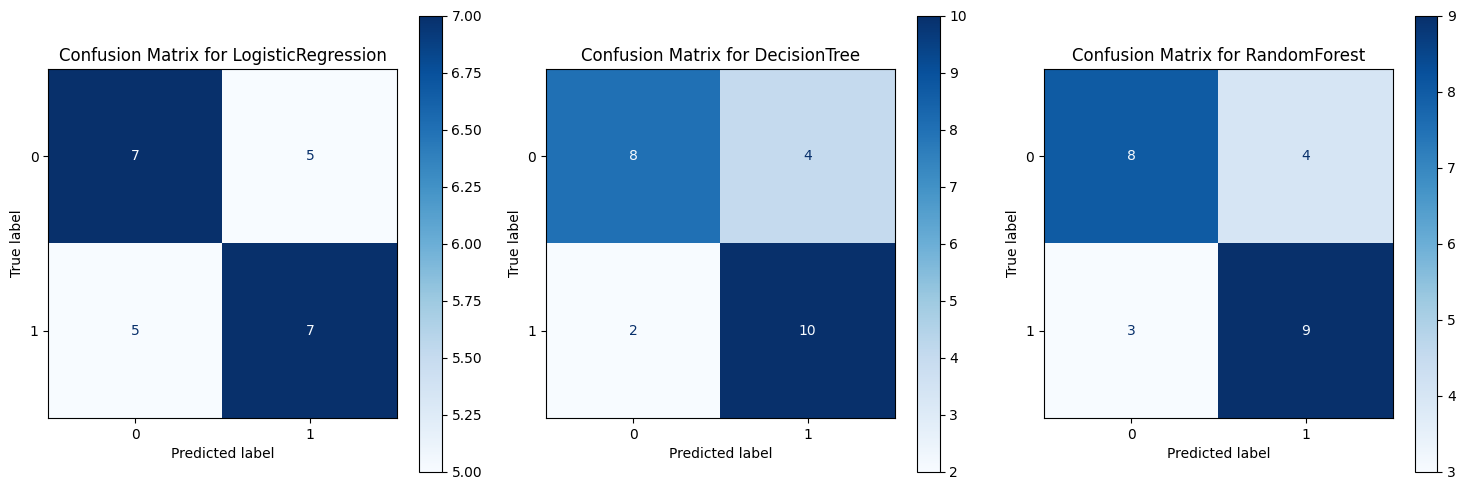

In [280]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

X_select = []
y = []
indexes = []
for i in dfNi.index:
    indexes.append(i)
    X_select.append(list(standardized_data.iloc[i].values) + [
            dfNi['Structure_integrity_after_rxn'].iloc[i],
            dfNi['Ni_M_ratio'].iloc[i]
        ])
    if not pd.isna(dfNi['Selectivity_1'].iloc[i]):
        y.append((dfNi['Yield_1'].iloc[i] * (1 - dfNi['Selectivity_1'].iloc[i]) +
                  dfNi['Yield_2'].iloc[i] * (1 - dfNi['Selectivity_2'].iloc[i])) / 2)
    else:
        y.append(0)

X_select = pd.DataFrame(X_select, index=indexes,
                        columns=list(standardized_data.columns) + ['stability', 'Ni_M_ratio'])

# Binarize y based on the median value
y_median = np.median(y)
y = [1 if value > y_median else 0 for value in y]
y = pd.DataFrame(y, index=indexes, columns=['Class'])

# 留一法测试
num_sample = len(np.unique(indexes))

# 初始化存储变量
test_and_predicted = [[] for _ in range(num_sample)]

# 不同的分类模型
models = {
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
}

trial_num = 0
for index in np.unique(indexes):
    print('Trial:', trial_num)
    # 构造 LOO 数据集
    X_train_val = X_select.drop([index])
    y_train_val = y.drop([index])
    X_test = X_select.loc[[index]]
    y_test = y.loc[[index]]

    for model_name, model in models.items():
        print(f"Model: {model_name}")
        
        # 训练模型
        model.fit(X_train_val, y_train_val.values.flatten())
        
        # 预测测试集
        y_pred_test = model.predict(X_test)
        y_pred_prob = model.predict_proba(X_test)[:, 1]  # 获取概率

        # 存储真实值和预测值
        test_and_predicted[trial_num].append([y_test.values[0][0], y_pred_test[0], y_pred_prob[0]])

    trial_num += 1

# 分类结果分析
models_list = list(models.keys())
accuracy_values = []
roc_auc_values = []
confusion_matrices = []  # 存储混淆矩阵
test_and_predicted = np.array(test_and_predicted)

# 计算分类指标
for i in range(len(models_list)):
    true_values = test_and_predicted[:, i, 0].astype(int)
    predicted_values = test_and_predicted[:, i, 1].astype(int)
    predicted_probs = test_and_predicted[:, i, 2]

    # 计算 Accuracy 和 ROC_AUC
    accuracy = accuracy_score(true_values, predicted_values)
    roc_auc = roc_auc_score(true_values, predicted_probs)

    accuracy_values.append(accuracy)
    roc_auc_values.append(roc_auc)

    # 计算混淆矩阵
    cm = confusion_matrix(true_values, predicted_values)
    confusion_matrices.append(cm)

# 打印平均指标
for model_name, accuracy, roc_auc in zip(models_list, accuracy_values, roc_auc_values):
    print(f"{model_name}:")
    print(f"  Mean Accuracy: {accuracy:.4f}")
    print(f"  Mean ROC_AUC: {roc_auc:.4f}")

# 可视化分类指标
plt.figure(figsize=(10, 5))

# 绘制 Accuracy
plt.subplot(1, 2, 1)
plt.bar(models_list, accuracy_values, color='skyblue')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy for Different Models')

# 绘制 ROC_AUC
plt.subplot(1, 2, 2)
plt.bar(models_list, roc_auc_values, color='lightgreen')
plt.xlabel('Model')
plt.ylabel('ROC AUC')
plt.title('ROC AUC for Different Models')

plt.tight_layout()
plt.show()

# 可视化混淆矩阵
plt.figure(figsize=(15, 5))
for i, cm in enumerate(confusion_matrices):
    plt.subplot(1, len(models_list), i + 1)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=plt.gca(), cmap="Blues", values_format="d")
    plt.title(f'Confusion Matrix for {models_list[i]}')

plt.tight_layout()
plt.show()


In [ ]:
# analysis of factors


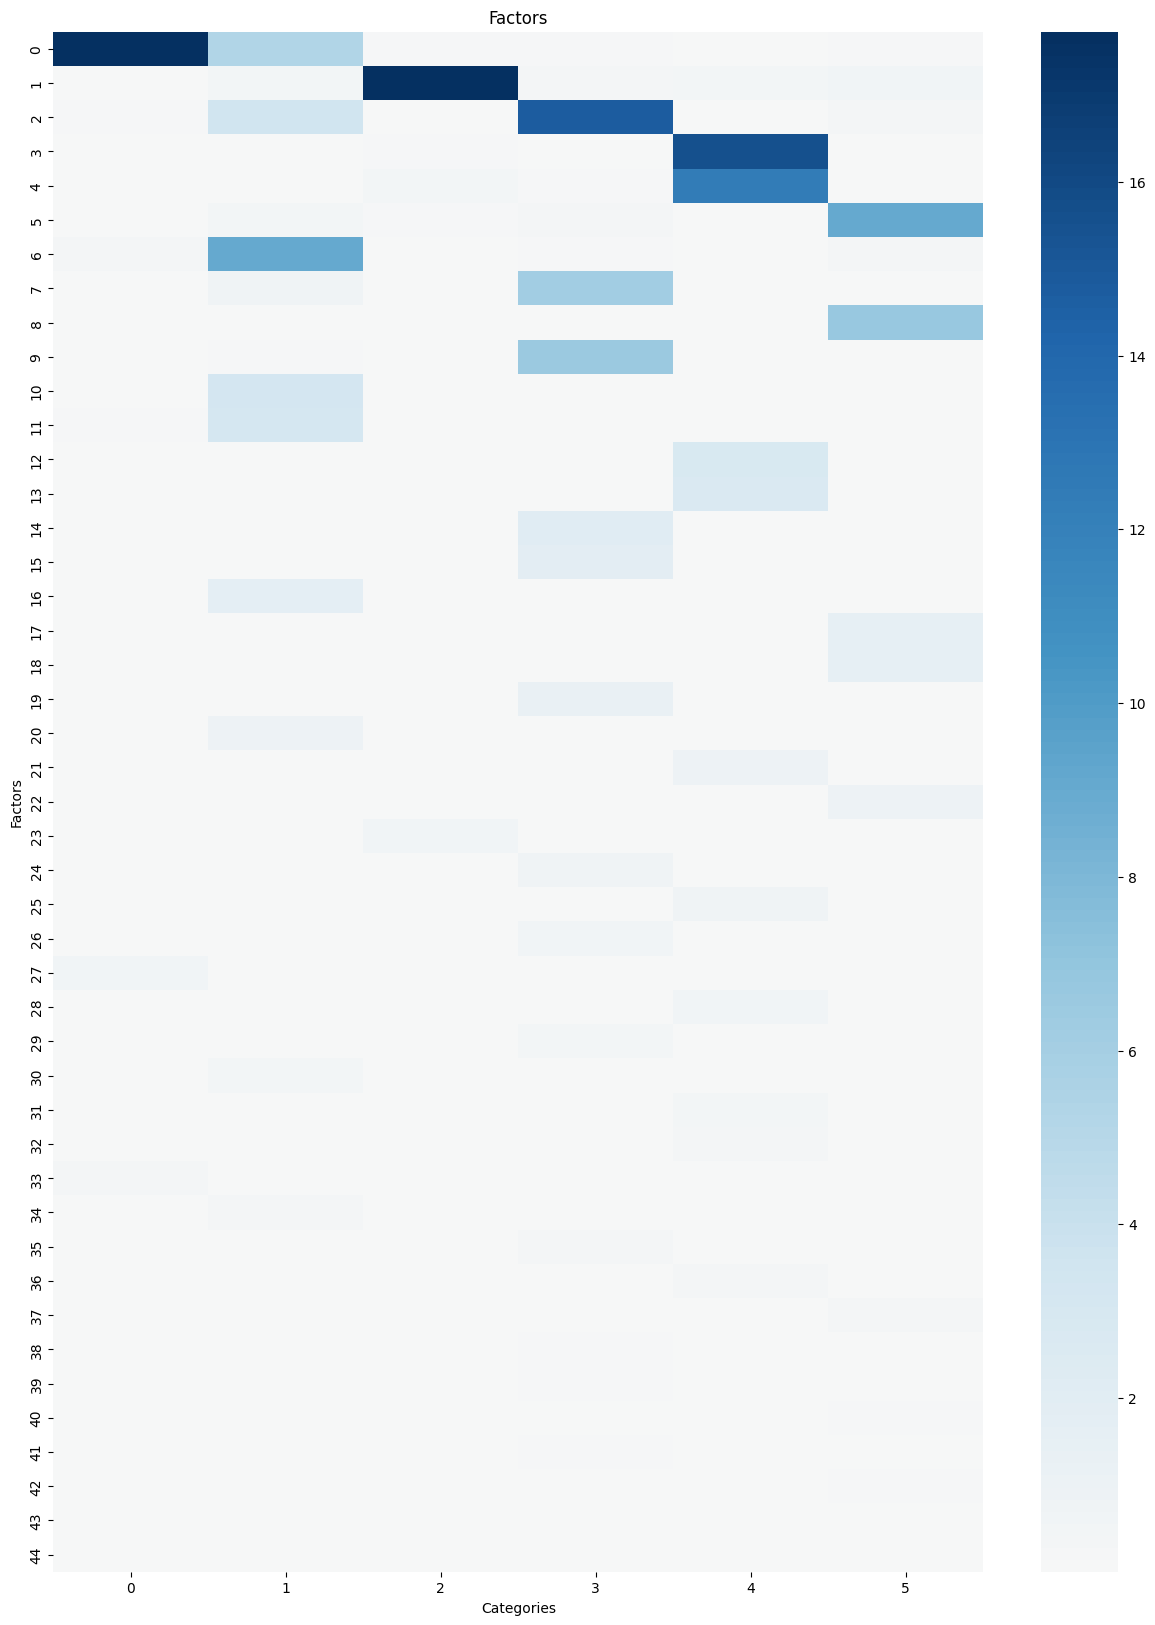

In [281]:
plt.figure(figsize=(15, 20))
sns.heatmap(categorizing_sum, cmap='RdBu', center = 0, annot=False)
plt.title('Factors')
plt.xlabel('Categories')
plt.ylabel('Factors')
plt.show()

In [90]:
from sklearn.preprocessing import MinMaxScaler
fscoeff_values = (factor_score_coefficients_df.values.T)**2
fscoeff_values = pd.DataFrame(fscoeff_values, columns=factor_score_coefficients_df.index)
categorizing_sum = np.zeros((factor_score_coefficients_df.shape[1],6))
for descriptor in list(loadings_df.index):
    if descriptor in framework_desc:
        categorizing_sum[:,0] += fscoeff_values[descriptor]
    elif descriptor in mc_desc:
        categorizing_sum[:,1] += fscoeff_values[descriptor]
    elif descriptor in lc_desc:
        categorizing_sum[:,2] += fscoeff_values[descriptor]
    elif descriptor in func_desc:
        categorizing_sum[:,3] += fscoeff_values[descriptor]
    elif descriptor in lig_desc:
        categorizing_sum[:,4] += fscoeff_values[descriptor]
    elif descriptor in pore_desc:
        categorizing_sum[:,5] += fscoeff_values[descriptor]

scaler = MinMaxScaler()
categorizing_sum = scaler.fit_transform(categorizing_sum.T).T
categorizing_sum = pd.DataFrame(categorizing_sum, columns=['framework','mc','lc','func','lig','pore'],index=loadings_df.columns)
categorized_descriptors = {'framework':framework_desc,
                           'mc':mc_desc,
                           'lc':lc_desc,
                           'func':func_desc,
                           'lig':lig_desc,
                           'pore':pore_desc}

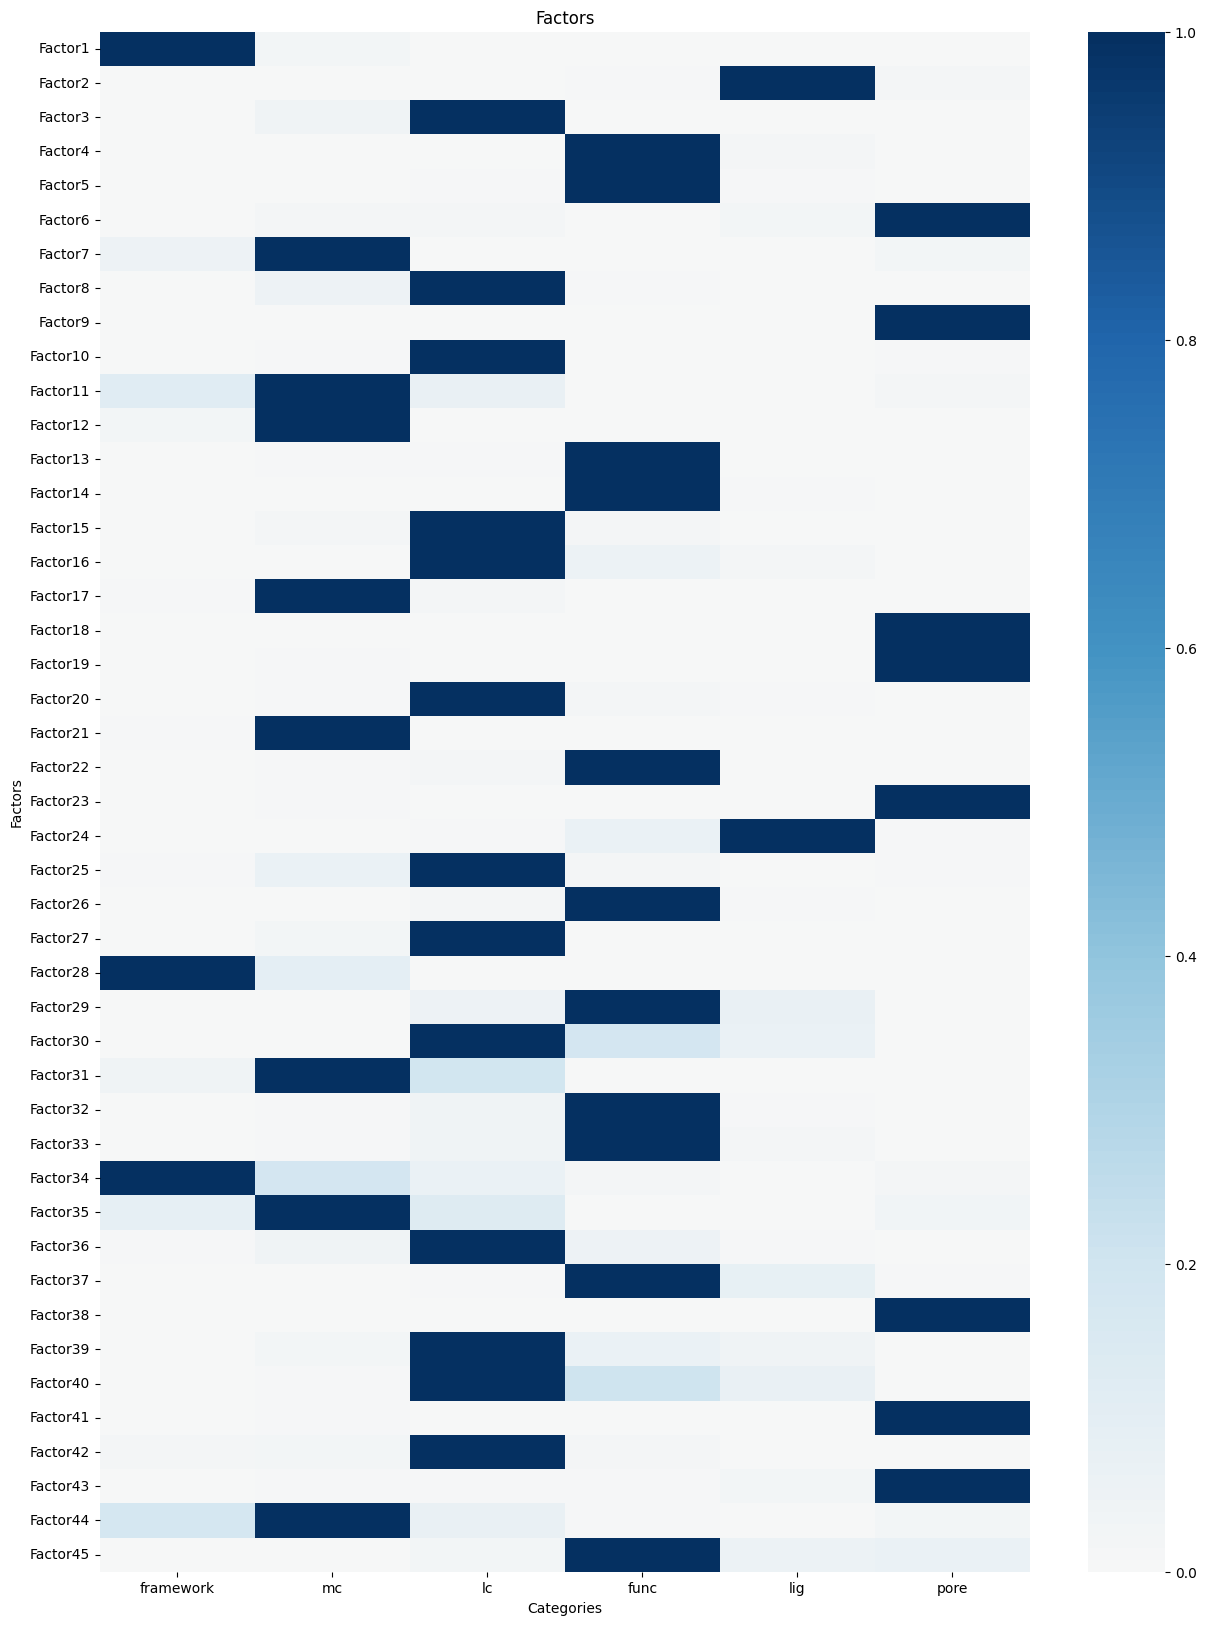

In [91]:
plt.figure(figsize=(15, 20))
sns.heatmap(categorizing_sum, cmap='RdBu', center = 0, annot=False)
plt.title('Factors')
plt.xlabel('Categories')
plt.ylabel('Factors')
plt.show()

Text(0, 0.5, 'values')

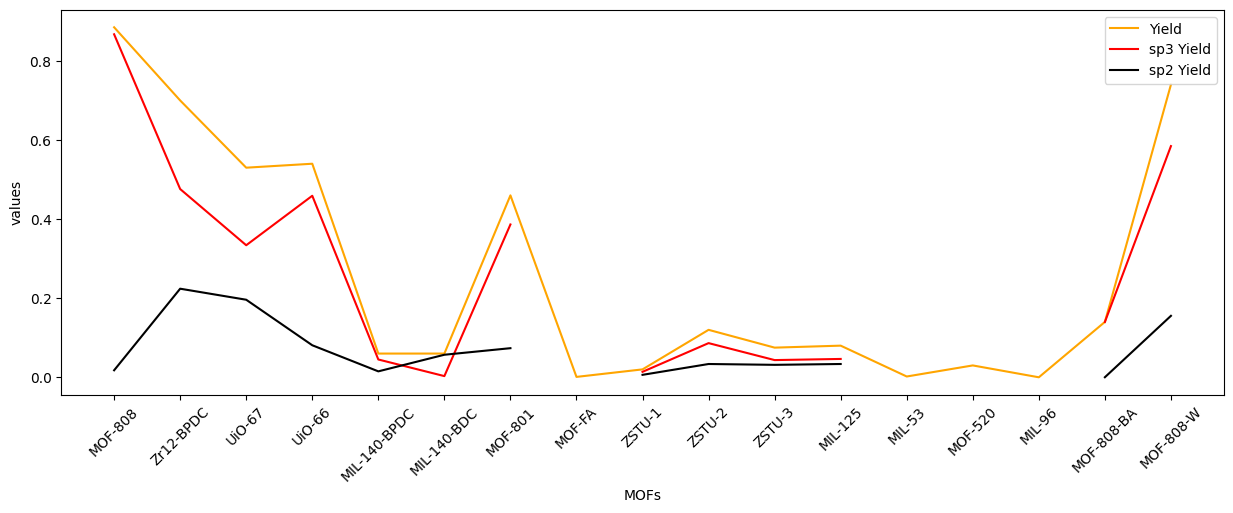

In [130]:
#examine activity

plt.figure(figsize=(15,5))
plt.plot(MOF_name.values, dfNi['Yield_mean'].values,color='orange')
plt.plot(MOF_name.values, dfNi['Yield_mean'].values*dfNi['Selectivity_mean'].values,color='red')
plt.plot(MOF_name.values, dfNi['Yield_mean'].values*(1-dfNi['Selectivity_mean'].values),color='black')
plt.legend(['Yield','sp3 Yield','sp2 Yield'])
plt.xlabel('MOFs')
plt.xticks(rotation=45)
plt.ylabel('values')

Text(0, 0.5, 'values')

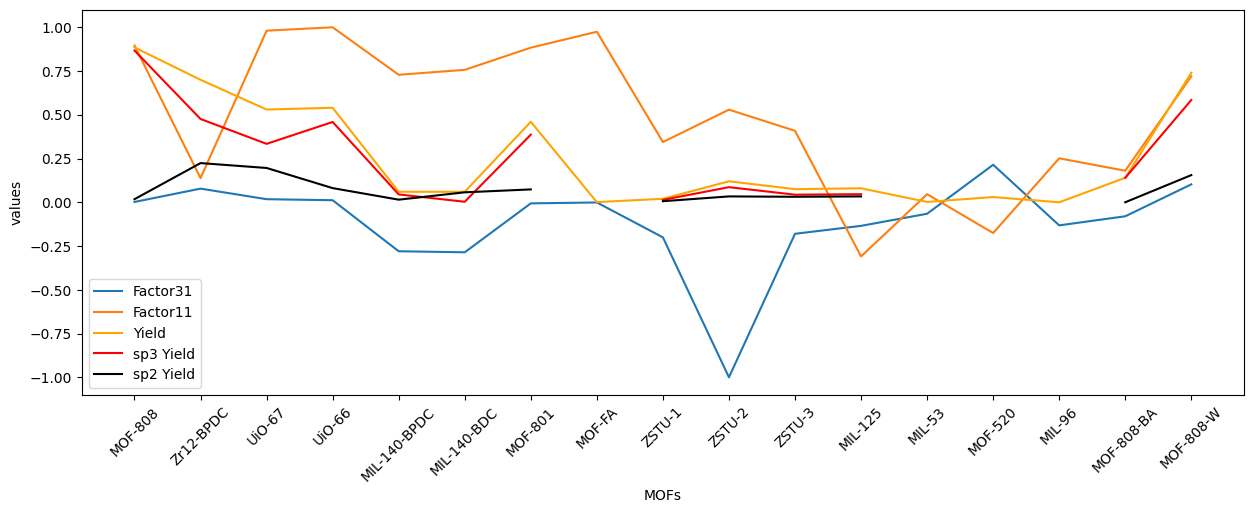

In [171]:
#examine factors

Factor_to_show = ['Factor31','Factor11']
plt.figure(figsize=(15,5))
for factor in Factor_to_show:
    plt.plot(MOF_name.values, factor_scores_dfX[factor].values/np.max(np.abs(factor_scores_dfX[factor].values)))
plt.plot(MOF_name.values, dfNi['Yield_mean'].values,color='orange')
plt.plot(MOF_name.values, dfNi['Yield_mean'].values*dfNi['Selectivity_mean'].values,color='red')
plt.plot(MOF_name.values, dfNi['Yield_mean'].values*(1-dfNi['Selectivity_mean'].values),color='black')
Factor_to_show.extend(['Yield','sp3 Yield','sp2 Yield'])
plt.legend(Factor_to_show)
plt.xlabel('MOFs')
plt.xticks(rotation=45)
plt.ylabel('values')

f-chi-0-all contribution to variation: 0.0013396102760232509
f-chi-1-all contribution to variation: 0.004547079814035682
f-chi-2-all contribution to variation: 0.01257655741715169
f-chi-3-all contribution to variation: 0.003774141093417338
f-Z-0-all contribution to variation: -0.001575743112340433
f-Z-1-all contribution to variation: -0.0007913650837472197
f-Z-2-all contribution to variation: 0.0023274490075495535
f-Z-3-all contribution to variation: 0.0010232291923948367
f-I-0-all contribution to variation: -0.003089977473607064
f-I-1-all contribution to variation: 0.0017694766655551586
f-I-2-all contribution to variation: 0.0032710272004308205
f-I-3-all contribution to variation: 0.0012873048916410834
f-T-0-all contribution to variation: 0.0016581773423036683
f-T-1-all contribution to variation: -0.0001436350429473432
f-T-2-all contribution to variation: 0.0018406997690978422
f-T-3-all contribution to variation: 0.005471517586965735
f-S-0-all contribution to variation: 1.114433647986

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129,
  130,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148,
  149,
  150,
  151,
  152,
  153,
  154,
  155,
  156,
  157,
  15

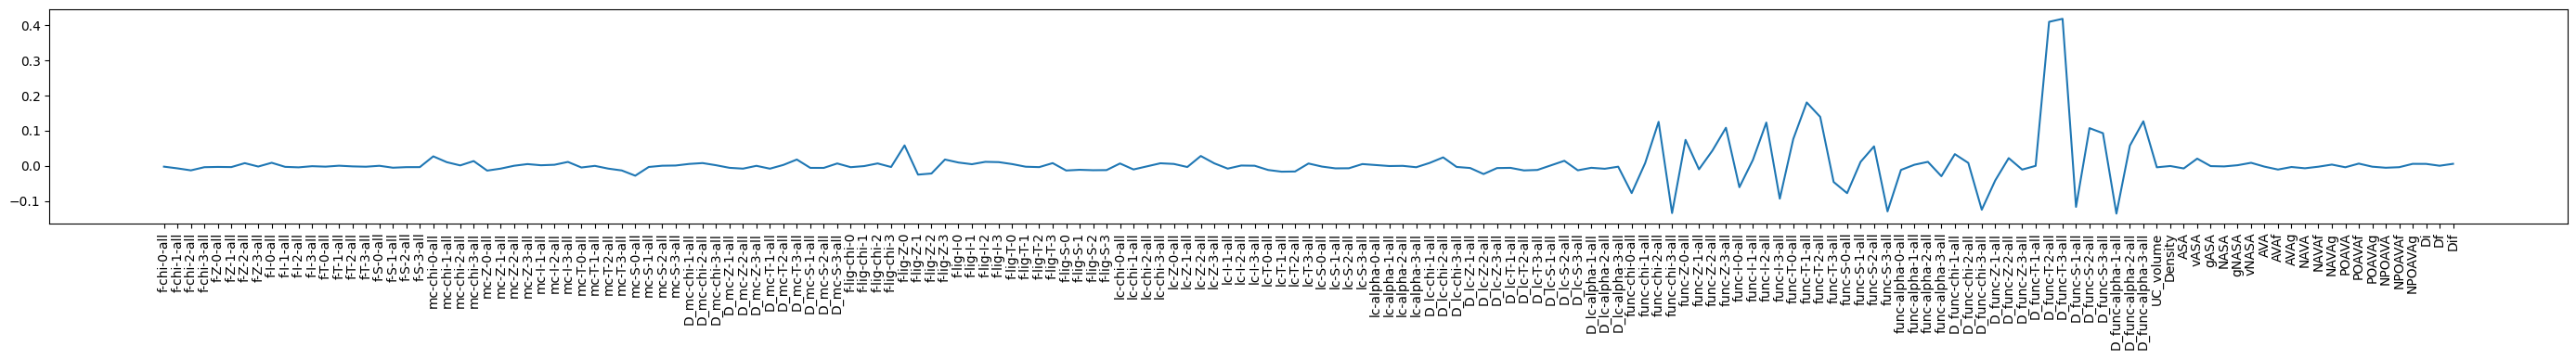

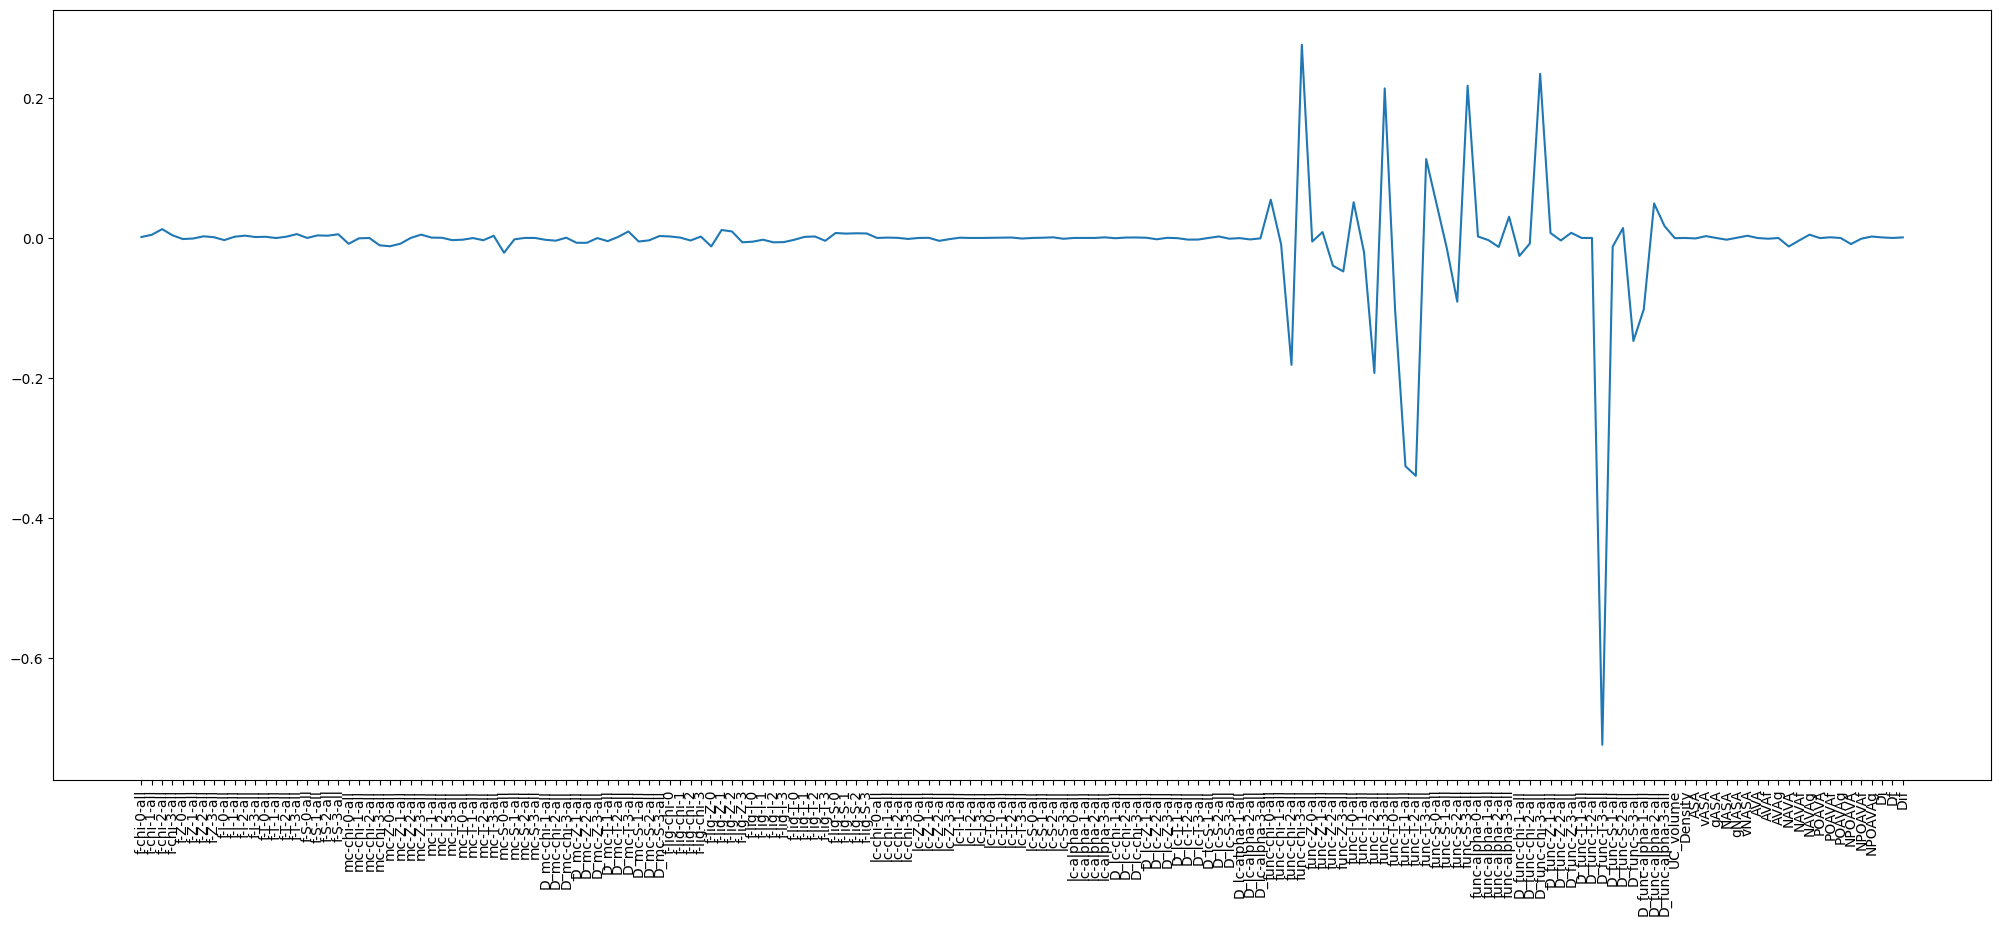

In [174]:
#examine a single factor

analyzed_factor = 'Factor14'

func_descriptors = [descriptor for descriptor in factor_score_coefficients_df.index if 'func' in descriptor]
non_func_descriptors = [descriptor for descriptor in factor_score_coefficients_df.index if 'func' not in descriptor]

plt.figure(figsize=(35,3))
plt.plot(factor_score_coefficients_df[analyzed_factor])
plt.xticks(rotation=90)


probed_matrix = dfX_standardized.values @ factor_score_coefficients_df[analyzed_factor].values

# 初始化列表来存储每列对结果的贡献
column_contributions = []

# 逐列分析
for i in range(dfX_standardized.values.shape[1]):
    # 创建一个副本矩阵
    A_zeroed = dfX_standardized.values.copy()
    
    # 将第 i 列置零
    A_zeroed[:, i] = 0
    
    # 计算新的结果向量
    probed_matrix_modified = A_zeroed @ factor_score_coefficients_df[analyzed_factor].values
    
    # 计算结果变化量（可以使用差值平方和或其他度量）
    change = probed_matrix_modified.std() - probed_matrix.std()
    
    # 存储每列的贡献
    column_contributions.append(change)

# 输出每列对结果的贡献
for i, contribution in enumerate(column_contributions):
    print(f"{dfX_standardized.columns[i]} contribution to variation: {contribution}")
plt.figure(figsize=(25,10))
plt.plot(dfX_standardized.columns,column_contributions)
plt.xticks(rotation=90)

<Axes: >

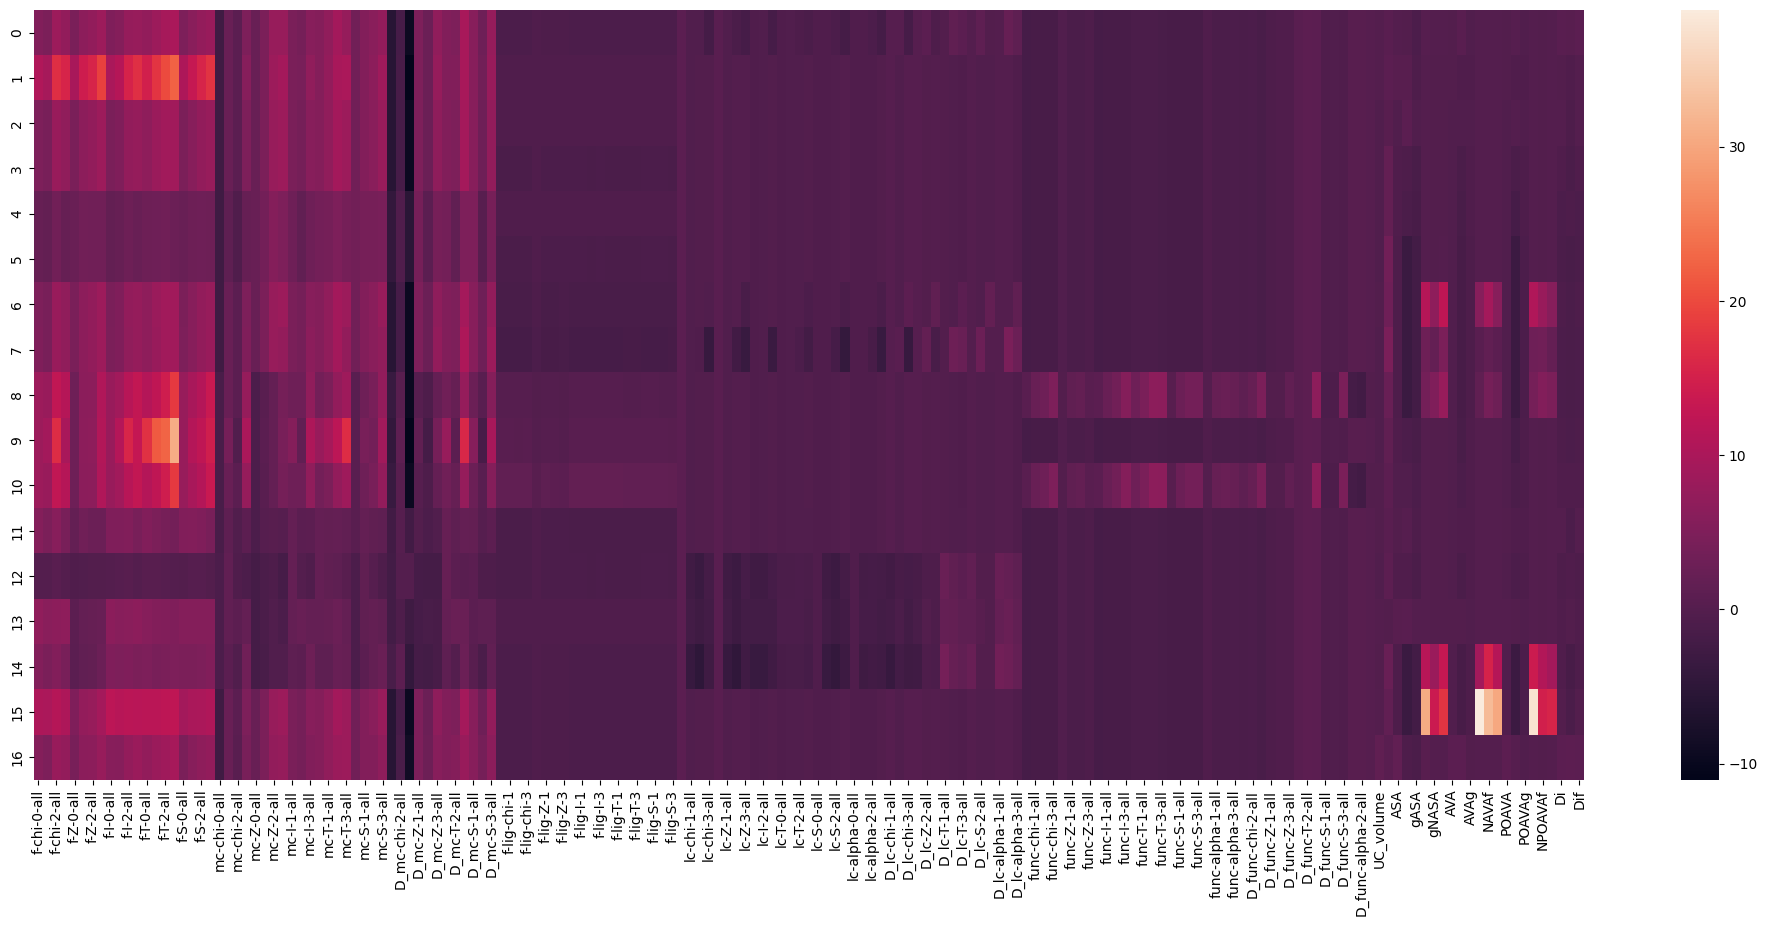

In [149]:
plt.figure(figsize=(25,10))
sns.heatmap(dfX_standardized)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'MOF-808'),
  Text(1, 0, 'Zr12-BPDC'),
  Text(2, 0, 'UiO-67'),
  Text(3, 0, 'UiO-66'),
  Text(4, 0, 'MIL-140-BPDC'),
  Text(5, 0, 'MIL-140-BDC'),
  Text(6, 0, 'MOF-801'),
  Text(7, 0, 'MOF-FA'),
  Text(8, 0, 'ZSTU-1'),
  Text(9, 0, 'ZSTU-2'),
  Text(10, 0, 'ZSTU-3'),
  Text(11, 0, 'MIL-125'),
  Text(12, 0, 'MIL-53'),
  Text(13, 0, 'MOF-520'),
  Text(14, 0, 'MIL-96')])

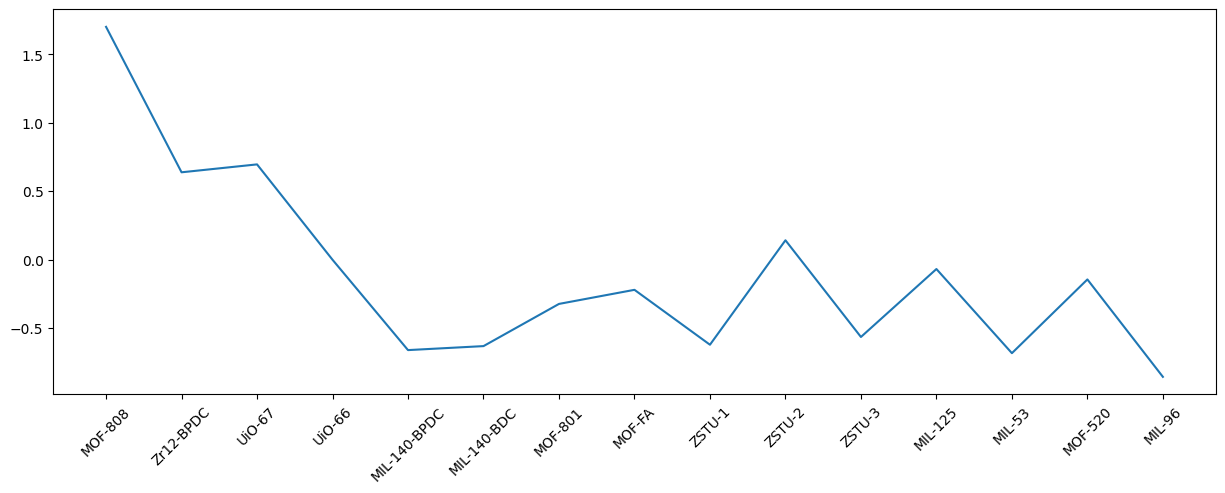

In [260]:
plt.figure(figsize=(15,5))
plt.plot(MOF_name.values, np.dot(dfX_standardized.values,factor_score_coefficients_df[analyzed_factor].values))
plt.xticks(rotation=45)